# Проект. Прогнозирование риска ДТП

## Введение

Современные сервисы каршеринга сталкиваются с проблемой обеспечения безопасности клиентов и минимизации ущерба транспортным средствам. Одним из перспективных направлений является разработка системы оценки риска дорожно-транспортного происшествия (ДТП) по выбранному маршруту. Такая система позволит своевременно предупреждать водителей о возможных опасностях и снизить вероятность аварий.

## Цель исследования

Цель работы — проверить возможность построения модели машинного обучения, способной предсказывать вероятность ДТП с повреждением автомобиля по вине водителя на основе исторических данных. 

В ходе исследования необходимо выявить факторы, оказывающие наибольшее влияние на риск аварии, и оценить перспективы внедрения подобной системы в каршеринговом бизнесе.

## Описание данных

Для анализа предоставлена база данных по происшествиям, включающая три взаимосвязанные таблицы:

* **collisions** — общая информация о ДТП (дата, время, место, погода, состояние дороги, освещённость, тип аварии, серьёзность повреждений и др.);

* **parties** — сведения об участниках происшествий (тип участника, вина, трезвость, физическое состояние, наличие телефона и др.);

* **vehicles** — характеристики автомобилей (тип кузова, трансмиссия, возраст и др.).

Целевой признак **at_fault** - виновность в аварии водителя арендованого автомобиля.

Связь между таблицами осуществляется через поле CASE_ID, а для уникальной идентификации участников используется комбинация CASE_ID и PARTY_NUMBER.

## План исследования

* [Подключение к базе данных](#link1)
* [Первичный осмотр таблиц](#link2)
* [Cтатистический анализ факторов ДТП](#link3)
* [Подготовка данных для создания модели](#link4)
* [Поиск лучшей модели](#link5)
* [Общий вывод](#link6)

## Подготовка рабочего пространства

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import phik
from phik import resources
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import torch
import torch.nn as nn
import torch.optim as optim
import random
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import shap

# импортируем мой модуль для DS
import ds_lib_tatarnikov as mylib

# настройки отображения таблиц
pd.options.display.max_columns = None

# отключим лишние предупреждения
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# зададим константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)  
torch.cuda.manual_seed_all(SEED)  
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

<a class='anchor' id="link1"></a>
## 1 Подключение к базе данных

Подключимся к базе данных.

In [2]:
# параметры подключения
db_config = {
    'user': 'praktikum_student',
    'password': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'database': 'data-science-vehicle-db'
}

# подключение
conn = psycopg2.connect(**db_config)

<a class='anchor' id="link2"></a>
## 2 Первичный осмотр таблиц

Загрузим первые строки каждой из трех таблиц.

In [3]:
query = "SELECT * FROM collisions LIMIT 5;"
df_collisions = pd.read_sql(query, conn)
display(df_collisions.head())
df_collisions.info()

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      5 non-null      object 
 1   county_city_location         5 non-null      object 
 2   county_location              5 non-null      object 
 3   distance                     5 non-null      float64
 4   direction                    1 non-null      object 
 5   intersection                 5 non-null      int64  
 6   weather_1                    5 non-null      object 
 7   location_type                1 non-null      object 
 8   collision_damage             5 non-null      object 
 9   party_count                  5 non-null      int64  
 10  primary_collision_factor     5 non-null      object 
 11  pcf_violation_category       5 non-null      object 
 12  type_of_collision            5 non-null      object 
 13  motor_vehicle_involved_w

In [4]:
query = "SELECT * FROM parties LIMIT 5;"
df_parties = pd.read_sql(query, conn)
display(df_parties.head())
df_parties.info()

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5 non-null      int64  
 1   case_id              5 non-null      object 
 2   party_number         5 non-null      int64  
 3   party_type           5 non-null      object 
 4   at_fault             5 non-null      int64  
 5   insurance_premium    4 non-null      float64
 6   party_sobriety       5 non-null      object 
 7   party_drug_physical  1 non-null      object 
 8   cellphone_in_use     5 non-null      int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 488.0+ bytes


In [5]:
query = "SELECT * FROM vehicles LIMIT 5;"
df_vehicles = pd.read_sql(query, conn)
display(df_vehicles.head())
df_vehicles.info()

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    5 non-null      int64 
 1   case_id               5 non-null      object
 2   party_number          5 non-null      int64 
 3   vehicle_type          5 non-null      object
 4   vehicle_transmission  5 non-null      object
 5   vehicle_age           5 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 368.0+ bytes


**Промежуточный итог:**

Было произведено успешное подключение к базе данных. Загружены первые строки таблиц.

В таблице collisions имеется признак control_device, которого нет в описании данных. Остальные столбцы и типы данных в таблицах соответствуют описанию. 

Имеется общий ключ **case_id** для связи таблиц.

<a class='anchor' id="link3"></a>
## 3 Cтатистический анализ факторов ДТП

**3.1 Статистика аварий по месяцам**

Посмотрим в какие месяцы происходит наибольшее количество аварий. Проанализируем весь период наблюдений.

In [6]:
query = """
SELECT 
    EXTRACT(YEAR FROM CAST(collision_date AS DATE)) AS year,
    EXTRACT(MONTH FROM CAST(collision_date AS DATE)) AS month,
    COUNT(DISTINCT EXTRACT(DAY FROM CAST(collision_date AS DATE))) AS days_count,
    COUNT(*) AS collisions_count
FROM collisions
GROUP BY year, month
ORDER BY year, month;
"""

df_collisions = pd.read_sql(query, conn)

Проверим полноту данных за представленный период.

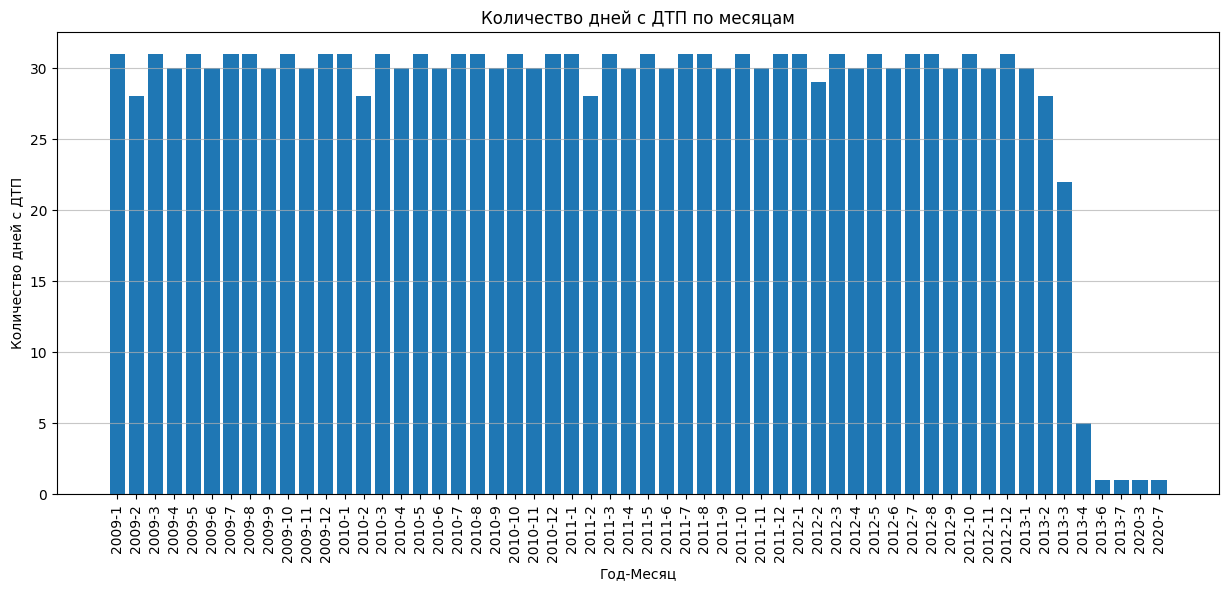

In [7]:
# Создаем колонку "год-месяц"
df_collisions['year_month'] = df_collisions['year'].astype(int).astype(str) + '-' + df_collisions['month'].astype(int).astype(str)

plt.figure(figsize=(15, 6))
plt.bar(df_collisions['year_month'], df_collisions['days_count'])
plt.xlabel('Год-Месяц')
plt.ylabel('Количество дней с ДТП')
plt.title('Количество дней с ДТП по месяцам')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.7)
plt.show()

В базе представленны данные за каждый день с начала 2009 по конец 2012 года. Данные за январь 2013 года и далее не полные. Для точности анализа предлагается информацию о ДТП начиная с 2013 года и далее не учитывать.

In [8]:
df_collisions = df_collisions[df_collisions['year'] < 2013]

Посмотрим на количество ДТП в каждом представленном месяце.

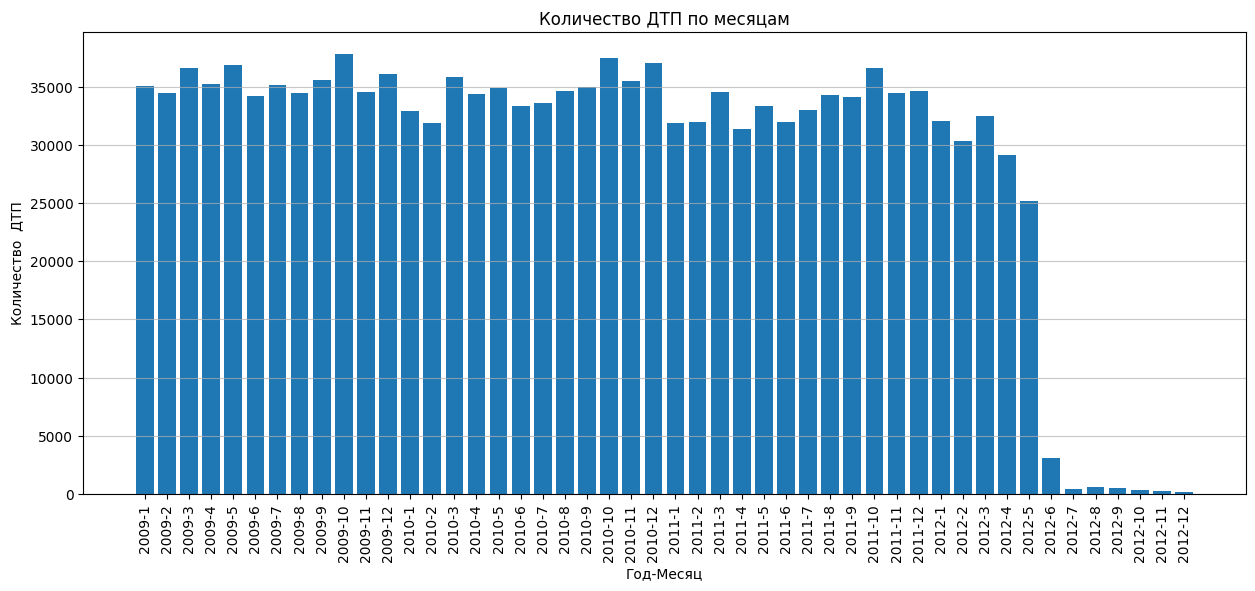

In [9]:
plt.figure(figsize=(15, 6))
plt.bar(df_collisions['year_month'], df_collisions['collisions_count'])
plt.xlabel('Год-Месяц')
plt.ylabel('Количество  ДТП')
plt.title('Количество ДТП по месяцам')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.7)
plt.show()

Судя по графику данные за 2012 год также представлены неполные. С июня по декабрь 2012 года количество дней с ДТП очень маленькое по сравнению с предыдущими годами. Исключим 2012 год из анализа количества ДТП по месяцам.

In [10]:
df_collisions = df_collisions[df_collisions['year'] < 2012]

Заменим номера месяцев на названия и визуализируем данные.

In [11]:
rus_months = {
    1.0: 'Январь', 2.0: 'Февраль', 3.0: 'Март',
    4.0: 'Апрель', 5.0: 'Май', 6.0: 'Июнь',
    7.0: 'Июль', 8.0: 'Август', 9.0: 'Сентябрь',
    10.0: 'Октябрь', 11.0: 'Ноябрь', 12.0: 'Декабрь'
}

df_collisions['month_name'] = df_collisions['month'].astype(int).map(rus_months)

In [12]:
df_collisions_grouped = df_collisions.groupby(['month', 'month_name'], as_index=False)['collisions_count'].sum()
#df_collisions_grouped

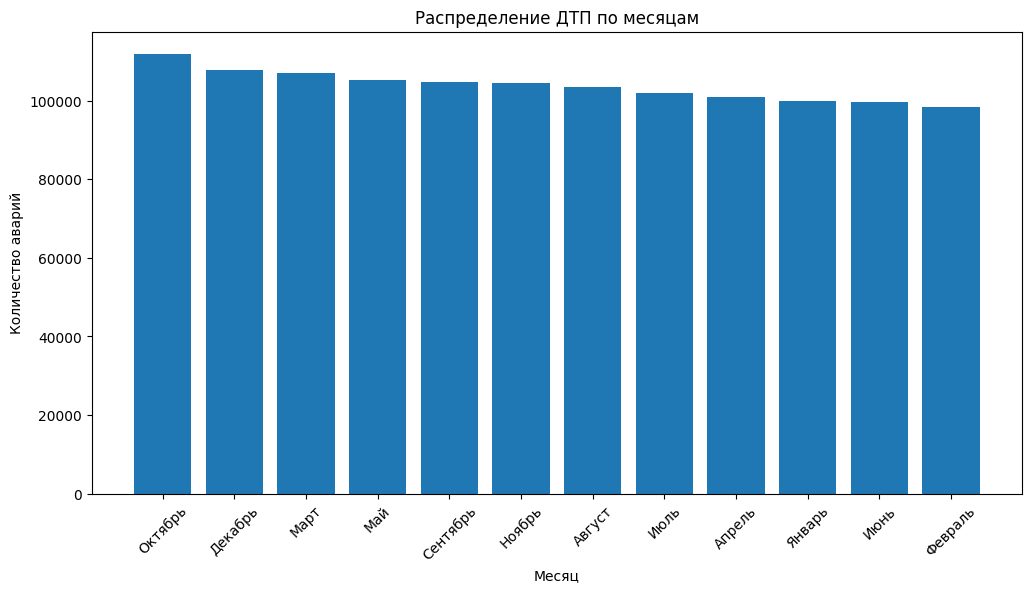

In [13]:
df_collisions_sorted = df_collisions_grouped.sort_values(by='collisions_count', ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_collisions_sorted['month_name'], df_collisions_sorted['collisions_count'])
plt.xlabel("Месяц")
plt.ylabel("Количество аварий")
plt.title("Распределение ДТП по месяцам")
plt.xticks(rotation=45)
plt.show()

В 2009 - 2011 годах наибольшее число аварий происходило в октябре, декабре, марте, наименьшее в январе, июне и феврале.

Нужно учесть, что в самых аварийноопасных месяцах 31 день, а в наименее аварийном феврале 28 дней.

Найдем среднедневное число аварий в каждом из месяцев.

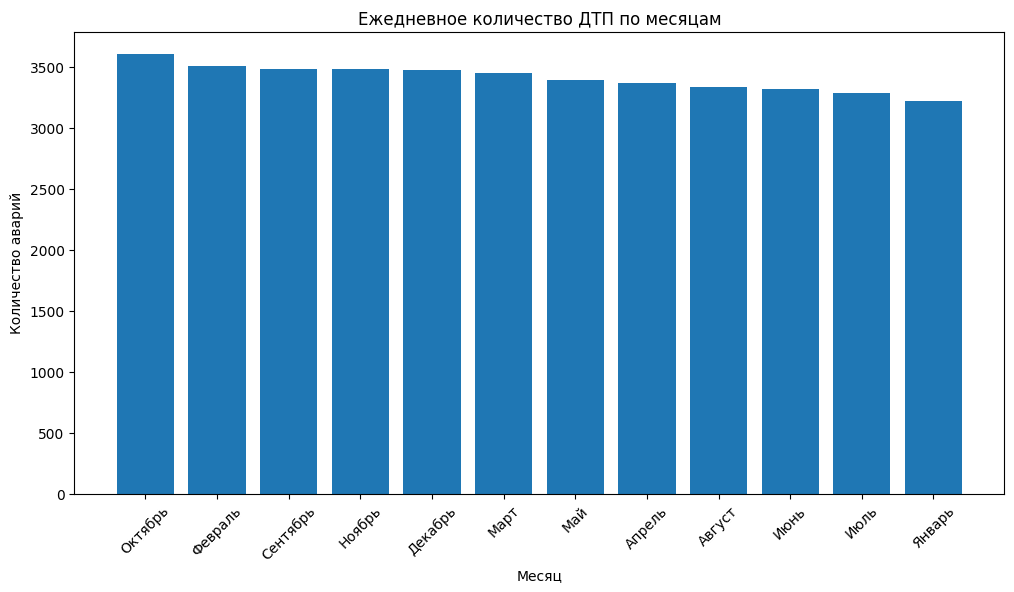

In [14]:
df_merged = pd.merge(df_collisions_grouped, df_collisions[df_collisions['year']==2009][['month','days_count']], on=['month'], how='inner')
df_merged[['collisions_daily']] = df_merged['collisions_count'] / df_merged['days_count']

df_merged = df_merged.sort_values(by='collisions_daily', ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_merged['month_name'], df_merged['collisions_daily'])
plt.xlabel("Месяц")
plt.ylabel("Количество аварий")
plt.title("Ежедневное количество ДТП по месяцам")
plt.xticks(rotation=45)
plt.show()

Анализ среднедневного числа ДТП показывает, что больше ДТП происходит в зимний период (с октября по март). Летние месяцы характеризуются меньшим количеством ежедневных ДТП. Исключение составляет январь, когда, несмотря на зимний сезон, наблюдается минимальное среднедневное количество аварий.

**3.2 Разработка аналитических задач**

1. Исследовать зависимость возраста автомобиля и тяжести последствий аварии.

2. Исследовать зависимость состояния участника ДТП с тяжестью последствий аварии.

3. Провести анализ влияния погодных условий на тяжесть последствий аварий.

4. Определить самые частые причины ДТП.

5. Исследовать связь между типом транспортного средства и типом повреждений

6. Определить дни недели, и врямя суток, когда происходит наибольшее число аварий.

**3.3 Связь между возрастом автомобиля и тяжестью последствий авариий**

Посмотрим на зависимость тяжести последствий аварии от возраста автомобиля.

In [15]:
query = """
SELECT 
    v.vehicle_age,
    c.collision_damage,
    COUNT(*)
FROM collisions c
JOIN vehicles v ON c.case_id = v.case_id
GROUP BY v.vehicle_age, c.collision_damage
ORDER BY v.vehicle_age;
"""

df_age_damage = pd.read_sql(query, conn)
df_age_damage.head()

,vehicle_age,collision_damage,count
0,0.0,fatal,229
1,0.0,middle damage,5951
2,0.0,scratch,10638
3,0.0,severe damage,812
4,0.0,small damage,22632


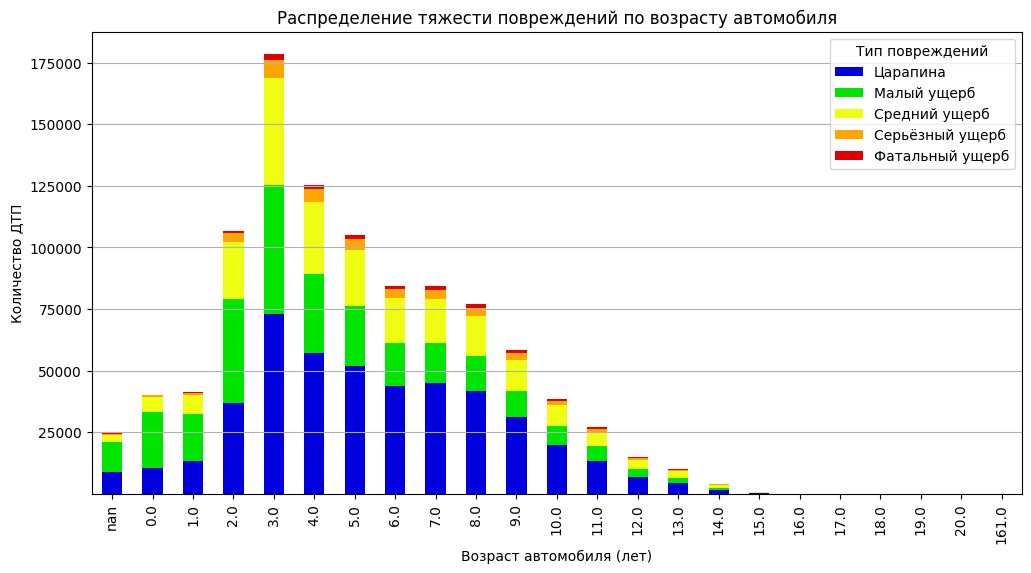

In [16]:
# группируем данные
pivot = df_age_damage.pivot(index='vehicle_age', columns='collision_damage', values='count').fillna(0)

# задаём порядок по тяжести (от лёгких к тяжёлым)
severity_order = ['scratch', 'small damage', 'middle damage', 'severe damage', 'fatal']
pivot = pivot[severity_order]

# переименовываем колонки на русский
russian_names = {
    'scratch': 'Царапина',
    'small damage': 'Малый ущерб',
    'middle damage': 'Средний ущерб',
    'severe damage': 'Серьёзный ущерб',
    'fatal': 'Фатальный ущерб'
}

# цвета по тяжести последствий
colors = {
    'Царапина': '#0000df',       
    'Малый ущерб': '#00e500',   
    'Средний ущерб': '#eefd11',  
    'Серьёзный ущерб': '#ffa500',  
    'Фатальный ущерб': '#df0000'           
}

pivot.rename(columns=russian_names, inplace=True)

# строим график
ax = pivot.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Возраст автомобиля (лет)')
plt.ylabel('Количество ДТП')
plt.title('Распределение тяжести повреждений по возрасту автомобиля')
plt.legend(title='Тип повреждений')
ax.yaxis.grid(True)
plt.show()

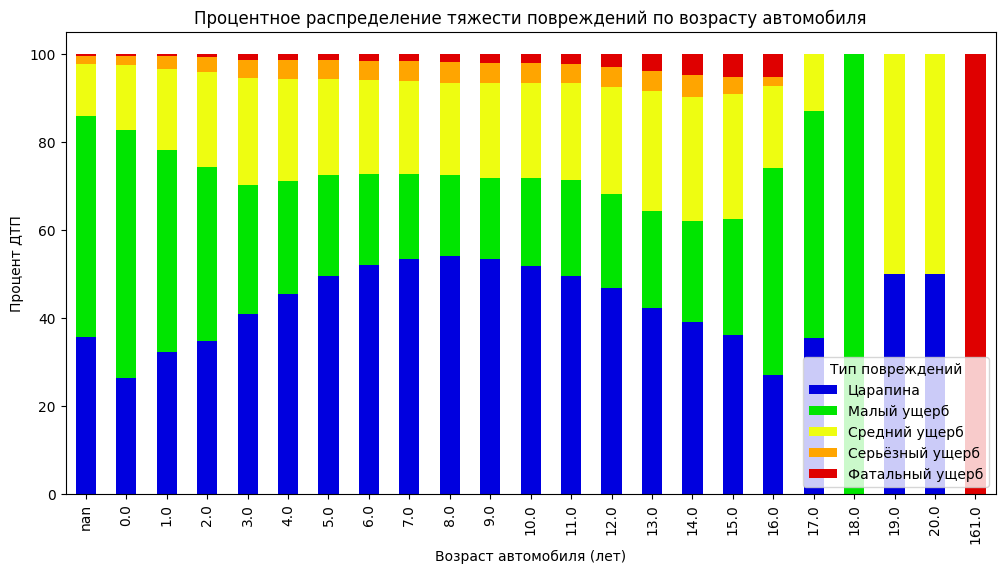

In [17]:
# считаем проценты по каждой возрастной группе
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_percent.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Возраст автомобиля (лет)')
plt.ylabel('Процент ДТП')
plt.title('Процентное распределение тяжести повреждений по возрасту автомобиля')
plt.legend(title='Тип повреждений')
plt.show()

Возраст автомобиля 161 год является аномалией.

Наибольшее число ДТП происходит с автомобилями с возрастом 3 года. Это может быть связано с тем, что автопарк компании в основном представлен автомобилями такого возраста.

Если предположить, что компания равномерно закупает новые автомобили, то можно сказать, что с увеличением возраста автомобиля увеличивается количество аварий.

График процентного распределения тяжести повреждений показывает, что с увеличением возраста автомобиля увеличивается количество аварий с серьезным и фатальным ущербом.

**3.4 Связь между состоянием участника ДТП и тяжестью последствий авариий**

Проведем анализ зависимости тяжести последствий аварии от состояния участника ДТП.

In [18]:
query = """
SELECT 
    p.party_drug_physical,
    c.collision_damage,
    COUNT(*)
FROM collisions c
JOIN parties p ON c.case_id = p.case_id
GROUP BY p.party_drug_physical, c.collision_damage
ORDER BY p.party_drug_physical;
"""

df_condition_damage = pd.read_sql(query, conn)
df_condition_damage.head()

,party_drug_physical,collision_damage,count
0,G,fatal,1871
1,G,middle damage,14281
2,G,scratch,34345
3,G,severe damage,4384
4,G,small damage,178020


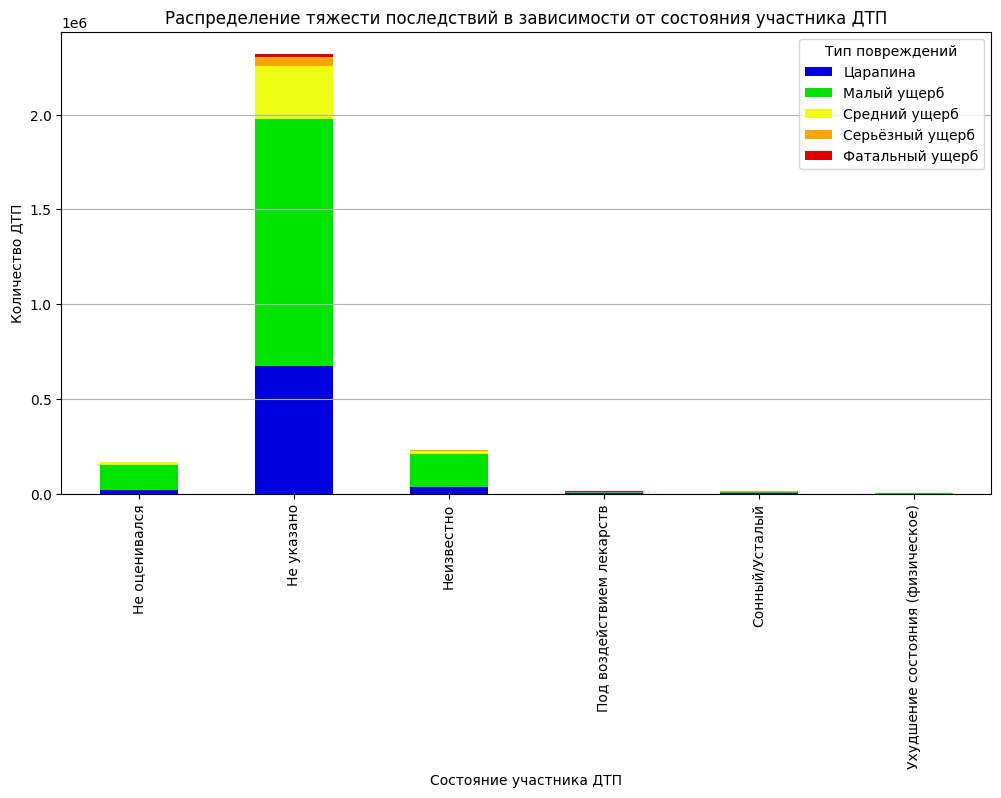

In [19]:
# заменяем на русские названия
party_map = {
    'G': 'Неизвестно',
    'impairment - physical': 'Ухудшение состояния (физическое)',
    'not applicable': 'Не оценивался',
    'sleepy/fatigued': 'Сонный/Усталый',
    'under drug influence': 'Под воздействием лекарств',
    None: 'Не указано'
}

df_condition_damage['party_drug_physical'] = df_condition_damage['party_drug_physical'].map(party_map)

# группируем через pivot_table
pivot = df_condition_damage.pivot_table(
    index='party_drug_physical',
    columns='collision_damage',
    values='count',
    aggfunc='sum'
).fillna(0)

# порядок по тяжести
severity_order = ['scratch', 'small damage', 'middle damage', 'severe damage', 'fatal']
for col in severity_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[severity_order]

# переименовываем колонки на русский
russian_names = {
    'scratch': 'Царапина',
    'small damage': 'Малый ущерб',
    'middle damage': 'Средний ущерб',
    'severe damage': 'Серьёзный ущерб',
    'fatal': 'Фатальный ущерб'
}
pivot.rename(columns=russian_names, inplace=True)

# цвета
colors = {
    'Царапина': '#0000df',       
    'Малый ущерб': '#00e500',   
    'Средний ущерб': '#eefd11',  
    'Серьёзный ущерб': '#ffa500',  
    'Фатальный ущерб': '#df0000'           
}

# график
ax = pivot.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Состояние участника ДТП')
plt.ylabel('Количество ДТП')
plt.title('Распределение тяжести последствий в зависимости от состояния участника ДТП')
plt.legend(title='Тип повреждений')
ax.yaxis.grid(True)
plt.show()

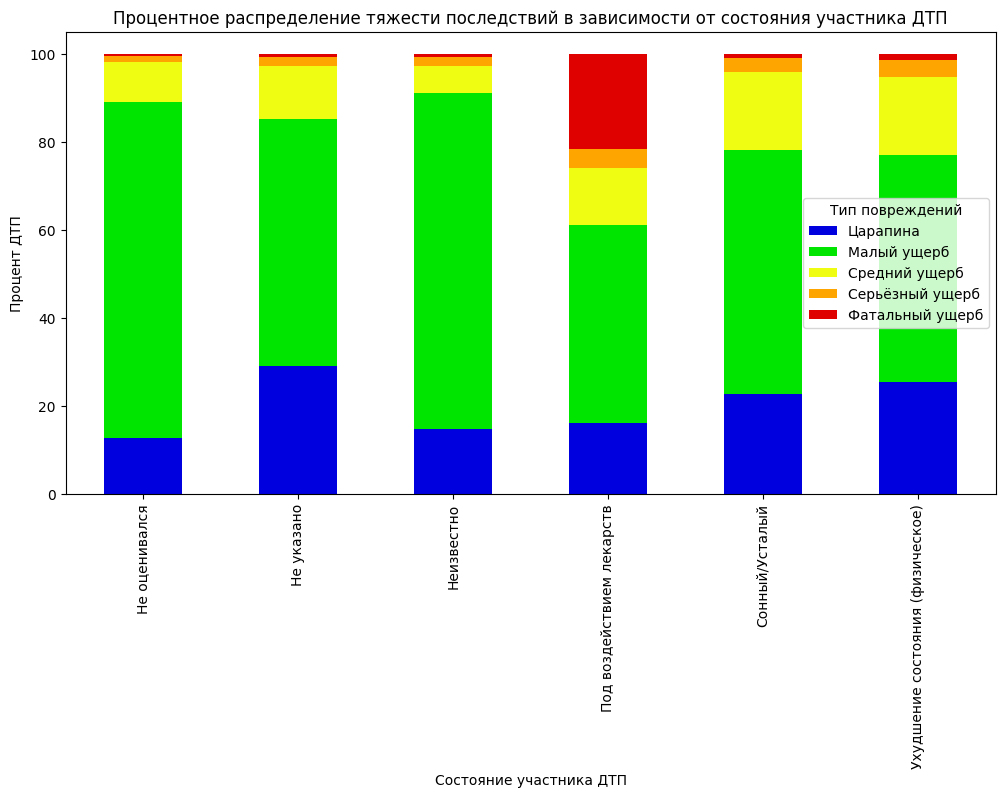

In [20]:
# считаем проценты по каждой группе
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_percent.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Состояние участника ДТП')
plt.ylabel('Процент ДТП')
plt.title('Процентное распределение тяжести последствий в зависимости от состояния участника ДТП')
plt.legend(title='Тип повреждений')
plt.show()

В большинстве случаев состояние участников ДТП не оценивается.

Ухудшенное физическое состояние чаще приводит к авариям с более серьезным ущербом.

Прием лекарств значительно увеличивает вероятность фатального исхода ДТП.

**Промежуточный итог:** 

Были предложены аналитические задачи для изучения и поиска закономерностей в представленных данных. Проведен анализ распределения аварий по месяцам, исследована связь между возрастом автомобиля и тяжестью последствий аварий и связь между состоянием участника ДТП и тяжестью последствий аварий.

<a class='anchor' id="link4"></a>
## 4 Подготовка данных для создания модели

**4.1 Выгрузка данных**

Для обучения модели выберем данные, которые потенциально можно знать до начала поездки и которые могут иметь связь с вероятностью ДТП.
Применим следующие ограничения:
- тип виновника - автомобиль,
- любые повреждения кроме царапины,
- данные только за 2012 год,
- обязательно учесть возраст автомобиля

In [21]:
query = """
SELECT
    -- collisions
    c.intersection,
    c.weather_1,
    c.road_surface,
    c.road_condition_1,
    c.lighting,
    c.control_device,
    c.distance,
    c.direction,
    c.county_city_location,
    c.county_location,
    
    -- parties
    p.at_fault,
    p.party_sobriety,
    p.party_drug_physical,
    p.cellphone_in_use,
    
    -- vehicles
    v.vehicle_type,
    v.vehicle_transmission,
    v.vehicle_age,
    
    -- time
    EXTRACT(MONTH FROM CAST(c.collision_date AS DATE)) AS month,
    EXTRACT(ISODOW FROM CAST(c.collision_date AS DATE)) AS day_of_week,
    EXTRACT(HOUR FROM c.collision_time) AS hour

FROM collisions c
JOIN parties p 
       ON c.case_id = p.case_id AND p.party_type = 'car'
JOIN vehicles v 
       ON c.case_id = v.case_id AND p.party_number = v.party_number
WHERE c.collision_damage != 'scratch'
  AND EXTRACT(YEAR FROM CAST(c.collision_date AS timestamp)) = 2012;
  
/*FROM collisions c
JOIN parties p ON c.case_id = p.case_id
JOIN vehicles v ON c.case_id = v.case_id
WHERE p.party_type = 'car'
  AND c.collision_damage != 'scratch'
  AND EXTRACT(YEAR FROM CAST(c.collision_date AS timestamp)) = 2012;*/
"""

df_prepared = pd.read_sql(query, conn)

# закрыть соединение
conn.close()

In [22]:
df_prepared.head()

,intersection,weather_1,road_surface,road_condition_1,lighting,control_device,distance,direction,county_city_location,county_location,at_fault,party_sobriety,party_drug_physical,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,month,day_of_week,hour
0,0.0,raining,wet,normal,daylight,none,1320.0,north,0100,alameda,0,had not been drinking,None,1.0,sedan,auto,12.0,4.0,3.0,19.0
1,0.0,clear,dry,construction,dark with street lights,functioning,435.0,east,3313,riverside,0,had not been drinking,None,0.0,sedan,auto,12.0,4.0,5.0,23.0
2,0.0,cloudy,dry,normal,daylight,none,2376.0,east,1992,los angeles,0,had not been drinking,None,1.0,sedan,auto,8.0,3.0,6.0,17.0
3,0.0,clear,dry,normal,daylight,none,443.0,north,3604,san bernardino,0,had not been drinking,None,0.0,sedan,auto,4.0,5.0,3.0,15.0
4,0.0,clear,dry,normal,daylight,none,50.0,south,3019,orange,1,had not been drinking,None,0.0,sedan,auto,7.0,5.0,5.0,17.0


In [23]:
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   intersection          56073 non-null  float64
 1   weather_1             56080 non-null  object 
 2   road_surface          55900 non-null  object 
 3   road_condition_1      55999 non-null  object 
 4   lighting              56094 non-null  object 
 5   control_device        56033 non-null  object 
 6   distance              56248 non-null  float64
 7   direction             43230 non-null  object 
 8   county_city_location  56248 non-null  object 
 9   county_location       56248 non-null  object 
 10  at_fault              56248 non-null  int64  
 11  party_sobriety        55376 non-null  object 
 12  party_drug_physical   2857 non-null   object 
 13  cellphone_in_use      51777 non-null  float64
 14  vehicle_type          56248 non-null  object 
 15  vehicle_transmissio

Полученная таблица состоит из 20 столбцов и 56248 строк. Имеются пропуски.

**4.2 Предобработка данных**

Удалим строки в столбцах, где пропусков относительно немного.

In [24]:
list_features = [
    'intersection',
    'weather_1', 
    'road_surface', 
    'road_condition_1', 
    'lighting', 
    'control_device', 
    'party_sobriety',
    'cellphone_in_use',
    'vehicle_type',
    'vehicle_transmission',
    'vehicle_age',
    'hour'
]

df_prepared.dropna(subset=list_features, inplace=True)

Посмотрим на уникальные значения в оставшихся столбцах.

In [25]:
df_prepared['direction'].unique()

array(['north', 'east', 'south', None, 'west'], dtype=object)

In [26]:
df_prepared['party_drug_physical'].unique()

array([None, 'not applicable', 'G', 'sleepy/fatigued',
       'under drug influence', 'impairment - physical'], dtype=object)

In [27]:
df_prepared['cellphone_in_use'].unique()

array([1., 0.])

Пропуски в столбце party_drug_physical заменим на 'G', что значит, что информация не указана.

In [28]:
df_prepared['party_drug_physical'].fillna('G', inplace=True)

В столбце direction для пропусков сделаем новую категорию na.

In [29]:
df_prepared['direction'].fillna('na', inplace=True)

In [30]:
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 48468 entries, 0 to 56247
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   intersection          48468 non-null  float64
 1   weather_1             48468 non-null  object 
 2   road_surface          48468 non-null  object 
 3   road_condition_1      48468 non-null  object 
 4   lighting              48468 non-null  object 
 5   control_device        48468 non-null  object 
 6   distance              48468 non-null  float64
 7   direction             48468 non-null  object 
 8   county_city_location  48468 non-null  object 
 9   county_location       48468 non-null  object 
 10  at_fault              48468 non-null  int64  
 11  party_sobriety        48468 non-null  object 
 12  party_drug_physical   48468 non-null  object 
 13  cellphone_in_use      48468 non-null  float64
 14  vehicle_type          48468 non-null  object 
 15  vehicle_transmissio

Все пропуски обработаны.

**4.3 Статистический анализ**

Посмотрим на статистическое описание данных.

In [31]:
df_prepared.describe(include='all')

,intersection,weather_1,road_surface,road_condition_1,lighting,control_device,distance,direction,county_city_location,county_location,at_fault,party_sobriety,party_drug_physical,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,month,day_of_week,hour
count,48468.000000,48468,48468,48468,48468,48468,4.846800e+04,48468,48468,48468,48468.000000,48468,48468,48468.000000,48468,48468,48468.000000,48468.000000,48468.000000,48468.000000
unique,NaN,7,4,8,5,4,NaN,5,483,58,NaN,6,5,NaN,3,2,NaN,NaN,NaN,NaN
top,NaN,clear,dry,normal,daylight,none,NaN,north,1942,los angeles,NaN,had not been drinking,G,NaN,sedan,manual,NaN,NaN,NaN,NaN
freq,NaN,38880,43494,46820,33375,33576,NaN,10775,5918,13790,NaN,43130,47612,NaN,32256,25500,NaN,NaN,NaN,NaN
mean,0.203103,NaN,NaN,NaN,NaN,NaN,9.314394e+02,NaN,NaN,NaN,0.498618,NaN,NaN,0.020137,NaN,NaN,4.855740,3.237394,4.162788,13.313836
std,0.402313,NaN,NaN,NaN,NaN,NaN,7.763791e+03,NaN,NaN,NaN,0.500003,NaN,NaN,0.140470,NaN,NaN,3.255736,1.805799,1.964347,5.445277
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,0.000000
25%,0.000000,NaN,NaN,NaN,NaN,NaN,1.500000e+01,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,3.000000,2.000000,2.000000,10.000000
50%,0.000000,NaN,NaN,NaN,NaN,NaN,1.570000e+02,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,4.000000,3.000000,4.000000,14.000000
75%,0.000000,NaN,NaN,NaN,NaN,NaN,6.500000e+02,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN,7.000000,4.000000,6.000000,17.000000


Иеется выброс в столбце с возрастом автомобиля (168 лет). 

В столбце с дистанцией от главной дороги имеются выбросы до 1,58 млн метров.

Распределения данных в остальных признаках выглядят естественными.

Для удобства визуализации переводем таблицу на русский язык.

In [32]:
columns_translate = {
    'intersection': 'Перекрёсток',
    'weather_1': 'Погода',
    'road_surface': 'Поверхность дороги',
    'road_condition_1': 'Состояние дороги',
    'lighting': 'Освещённость',
    'control_device': 'Устройство регулирования',
    'distance': 'Дистанция',
    'direction': 'Направление',
    'county_city_location': 'Местоположение (код)',
    'county_location': 'Местоположение (округ)',
    'at_fault': 'Виновник ДТП',
    'party_sobriety': 'Трезвость водителя',
    'party_drug_physical': 'Состояние водителя',
    'cellphone_in_use': 'Громкая связь',
    'vehicle_type': 'Тип автомобиля',
    'vehicle_transmission': 'Коробка передач',
    'vehicle_age': 'Возраст автомобиля',
    'month': 'Месяц',
    'day_of_week': 'День недели',
    'hour': 'Время'
}

values_translate = {
    # Направление
    'east': 'Восток',
    'north': 'Север',
    'south': 'Юг',
    'west': 'Запад',
    'na': 'Неизвестно',

    # Состояние водителя
    'G': 'Неизвестно',
    'not applicable': 'Не оценивался',
    'under drug influence': 'Под воздействием наркотиков',
    'sleepy/fatigued': 'Сонный/Усталый',
    'impairment - physical': 'Физическое ухудшение',
    'impairment unknown': 'Ухудшение неизвестно',
    'had not been drinking': 'Не пил',
    'had been drinking, under influence': 'Был пьян, под влиянием',
    'had been drinking, not under influence': 'Был пьян, не под влиянием',
    'had been drinking, impairment unknown': 'Был пьян, ухудшение неизвестно',

    # Тип автомобиля
    'sedan': 'Седан',
    'coupe': 'Купе',
    'other': 'Прочее',

    # Тип коробки передач
    'auto': 'Автомат',
    'manual': 'Механика',

    # Местоположение (округ)
    'san diego': 'Сан-Диего',
    'los angeles': 'Лос-Анджелес',
    'alameda': 'Аламеда',
    'orange': 'Оранж',
    'santa clara': 'Санта-Клара',
    'san mateo': 'Сан-Матео',
    'san luis obispo': 'Сан-Луис-Обиспо',
    'sonoma': 'Сонома',
    'riverside': 'Риверсайд',
    'san joaquin': 'Сан-Хоакин',
    'solano': 'Солано',
    'san bernardino': 'Сан-Бернардино',
    'madera': 'Мадера',
    'monterey': 'Монтерей',
    'stanislaus': 'Станислаус',
    'santa barbara': 'Санта-Барбара',
    'marin': 'Марин',
    'butte': 'Батт',
    'kern': 'Керн',
    'tulare': 'Туларе',
    'ventura': 'Вентура',
    'nevada': 'Невада',
    'colusa': 'Колуса',
    'sacramento': 'Сакраменто',
    'del norte': 'Дел-Норте',
    'contra costa': 'Контра-Коста',
    'fresno': 'Фресно',
    'san francisco': 'Сан-Франциско',
    'yuba': 'Юба',
    'shasta': 'Шаста',
    'imperial': 'Империал',
    'mariposa': 'Марипоса',
    'siskiyou': 'Сискию',
    'modoc': 'Модок',
    'santa cruz': 'Санта-Круз',
    'humboldt': 'Хамбольт',
    'yolo': 'Йоло',
    'tehama': 'Техама',
    'amador': 'Амадор',
    'merced': 'Мерсед',
    'napa': 'Напа',
    'lake': 'Лейк',
    'san benito': 'Сан-Бенито',
    'kings': 'Кингс',
    'inyo': 'Иньо',
    'placer': 'Плейсер',
    'glenn': 'Гленн',
    'mendocino': 'Мендосино',
    'el dorado': 'Эль-Дорадо',
    'sutter': 'Саттер',
    'tuolumne': 'Туолумне',
    'trinity': 'Тринити',
    'lassen': 'Лассен',
    'plumas': 'Плумас',
    'calaveras': 'Калаверас',
    'alpine': 'Альпайн',
    'mono': 'Моно',
    'sierra': 'Сьерра',

    # Устройство регулирования
    'none': 'Нет',
    'functioning': 'Работает',
    'obscured': 'Затемнено',
    'not functioning': 'Не работает',

    # Освещённость
    'daylight': 'Дневной свет',
    'dark with no street lights': 'Темно — без фонарей',
    'dark with street lights': 'Темно — с фонарями',
    'dusk or dawn': 'Сумерки/Рассвет',
    'dark with street lights not functioning': 'Темно — фонари не работают',

    # Состояние дороги
    'normal': 'Норма',
    'construction': 'Ремонт',
    'holes': 'Ямы',
    'obstruction': 'Препятствие',
    'reduced width': 'Сужение проезжей части',
    'loose material': 'Сыпучий материал',
    'flooded': 'Затоплено',
    'other': 'Прочее',

    # Покрытие дороги
    'dry': 'Сухая',
    'slippery': 'Скользкая',
    'wet': 'Мокрая',
    'snowy': 'Снежная',

    # Погода
    'clear': 'Ясно',
    'cloudy': 'Облачно',
    'raining': 'Дождь',
    'fog': 'Туман',
    'snowing': 'Снег',
    'wind': 'Ветер',
    'other': 'Прочее'
}

df_prepared_rus=df_prepared.rename(columns=columns_translate)

for col in df_prepared_rus.select_dtypes(include='object').columns:
    df_prepared_rus[col] = df_prepared_rus[col].map(values_translate).fillna(df_prepared_rus[col])

yes_no_map = {0.0: 'Нет', 1.0: 'Да'}
cols_binary = ['Перекрёсток', 'Виновник ДТП', 'Громкая связь']
for col in cols_binary:
    df_prepared_rus[col] = df_prepared_rus[col].map(yes_no_map)

df_prepared_rus

,Перекрёсток,Погода,Поверхность дороги,Состояние дороги,Освещённость,Устройство регулирования,Дистанция,Направление,Местоположение (код),Местоположение (округ),Виновник ДТП,Трезвость водителя,Состояние водителя,Громкая связь,Тип автомобиля,Коробка передач,Возраст автомобиля,Месяц,День недели,Время
0,Нет,Дождь,Мокрая,Норма,Дневной свет,Нет,1320.0,Север,0100,Аламеда,Нет,Не пил,Неизвестно,Да,Седан,Автомат,12.0,4.0,3.0,19.0
1,Нет,Ясно,Сухая,Ремонт,Темно — с фонарями,Работает,435.0,Восток,3313,Риверсайд,Нет,Не пил,Неизвестно,Нет,Седан,Автомат,12.0,4.0,5.0,23.0
2,Нет,Облачно,Сухая,Норма,Дневной свет,Нет,2376.0,Восток,1992,Лос-Анджелес,Нет,Не пил,Неизвестно,Да,Седан,Автомат,8.0,3.0,6.0,17.0
3,Нет,Ясно,Сухая,Норма,Дневной свет,Нет,443.0,Север,3604,Сан-Бернардино,Нет,Не пил,Неизвестно,Нет,Седан,Автомат,4.0,5.0,3.0,15.0
4,Нет,Ясно,Сухая,Норма,Дневной свет,Нет,50.0,Юг,3019,Оранж,Да,Не пил,Неизвестно,Нет,Седан,Автомат,7.0,5.0,5.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56243,Нет,Дождь,Снежная,Норма,Дневной свет,Нет,10.0,Восток,4008,Сан-Луис-Обиспо,Нет,Не пил,Неизвестно,Нет,Купе,Автомат,9.0,4.0,5.0,18.0
56244,Нет,Ясно,Сухая,Норма,Дневной свет,Нет,60.0,Восток,1946,Лос-Анджелес,Да,Не пил,Неизвестно,Нет,Купе,Механика,4.0,1.0,3.0,12.0
56245,Да,Ясно,Сухая,Норма,Темно — с фонарями,Работает,0.0,Неизвестно,3008,Оранж,Да,"Был пьян, под влиянием",Неизвестно,Нет,Купе,Механика,6.0,4.0,6.0,4.0
56246,Нет,Ясно,Сухая,Норма,Дневной свет,Работает,14784.0,Запад,3700,Сан-Диего,Да,Не пил,Неизвестно,Нет,Купе,Механика,7.0,4.0,7.0,14.0


Для удобства визуализации разделим таблицу на две части по целевому признаку.

In [33]:
df0 = df_prepared_rus[df_prepared_rus['Виновник ДТП'] == 'Нет']
df1 = df_prepared_rus[df_prepared_rus['Виновник ДТП'] == 'Да']

Построим круговую диаграмму для целевого признака.

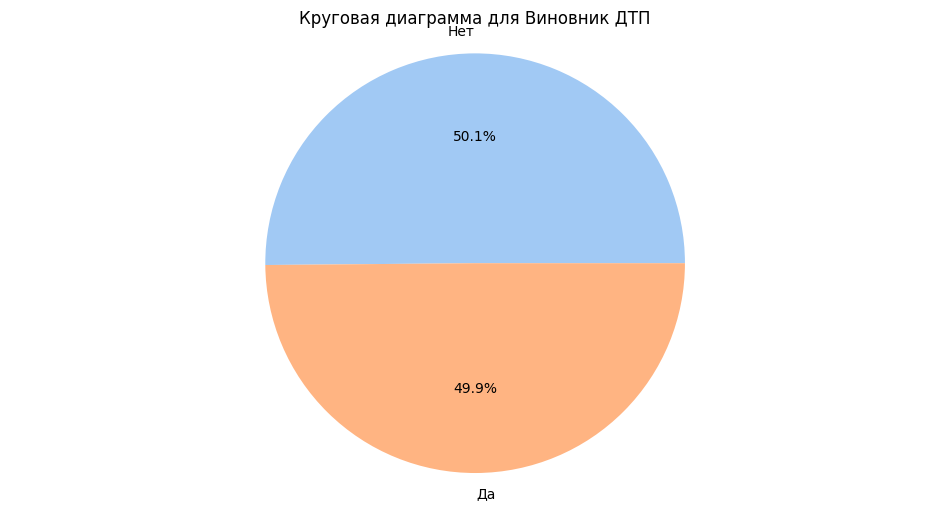

In [34]:
mylib.show_pie(df_prepared_rus, 'Виновник ДТП')

Данные сбалансированы по целевому признаку.

Выведем круговые и столбчатые диаграммы для категориальных прихнаков. 

In [35]:
features = [
    'Перекрёсток',
    'Погода',
    'Поверхность дороги',
    'Состояние дороги',
    'Освещённость',
    'Устройство регулирования',
    'Трезвость водителя',
    'Состояние водителя',
    'Громкая связь',
    'Тип автомобиля',
    'Коробка передач',
    'Направление'
]

features_2 = [
    'Местоположение (округ)',
    'Местоположение (код)'
]

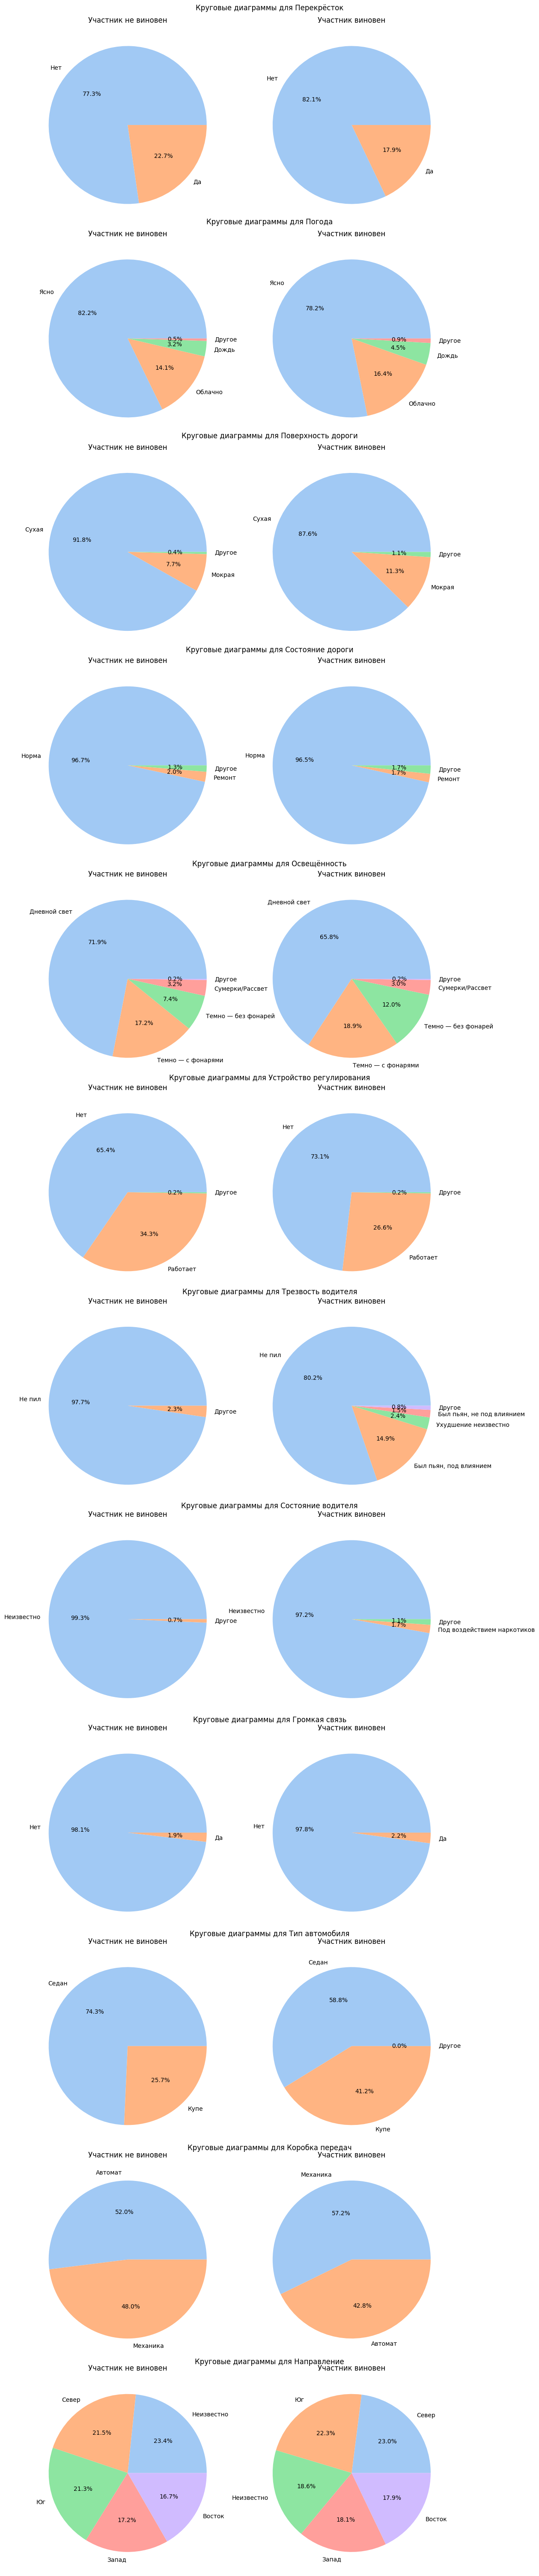

In [36]:
mylib.show_2_pies(df0, df1, features, df_label='Участник не виновен', df2_label='Участник виновен', threshold=0.01)

Имеется слабая разница в распределениях данных с разбивкой по таргету в столбцах:

Перекресток, Погода, Поверхность дороги, Освещенность, Устройство регулирования, Состояние водителя, Тип автомобиля, Коробка передач.

Распределения данных сильно отличаются в столбце Трезвость водителя

Посмотрим распределение данных в зависимости от местоположения с разбивкой по целевому признаку.

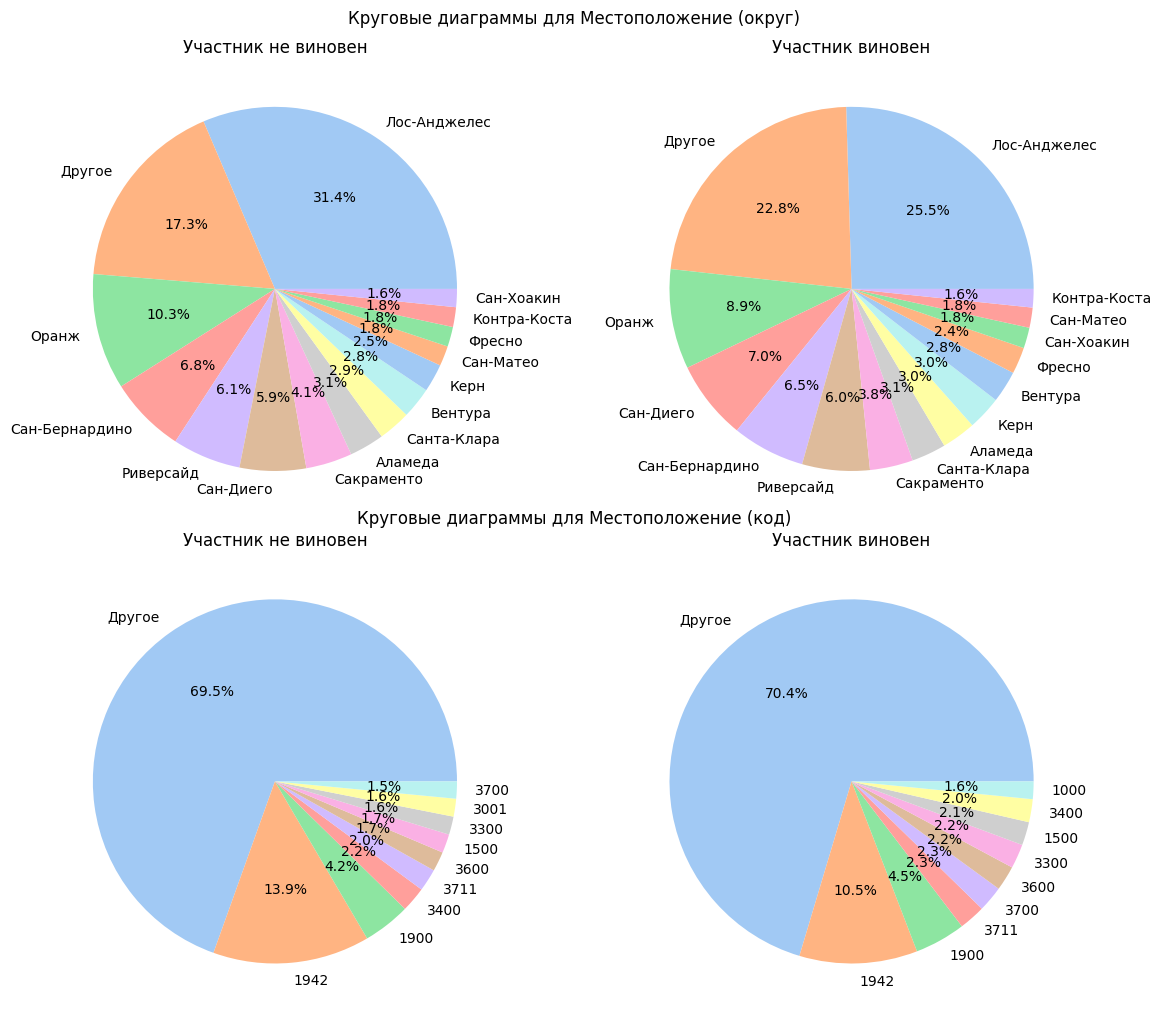

In [37]:
mylib.show_2_pies(df0, df1, features_2, df_label='Участник не виновен', df2_label='Участник виновен', threshold=0.015)

Круговые диаграммы для местоположения оказались малоинформативны. Найдем относительное количество аварий с виной участника в каждом местоположении и визуализируем данные.

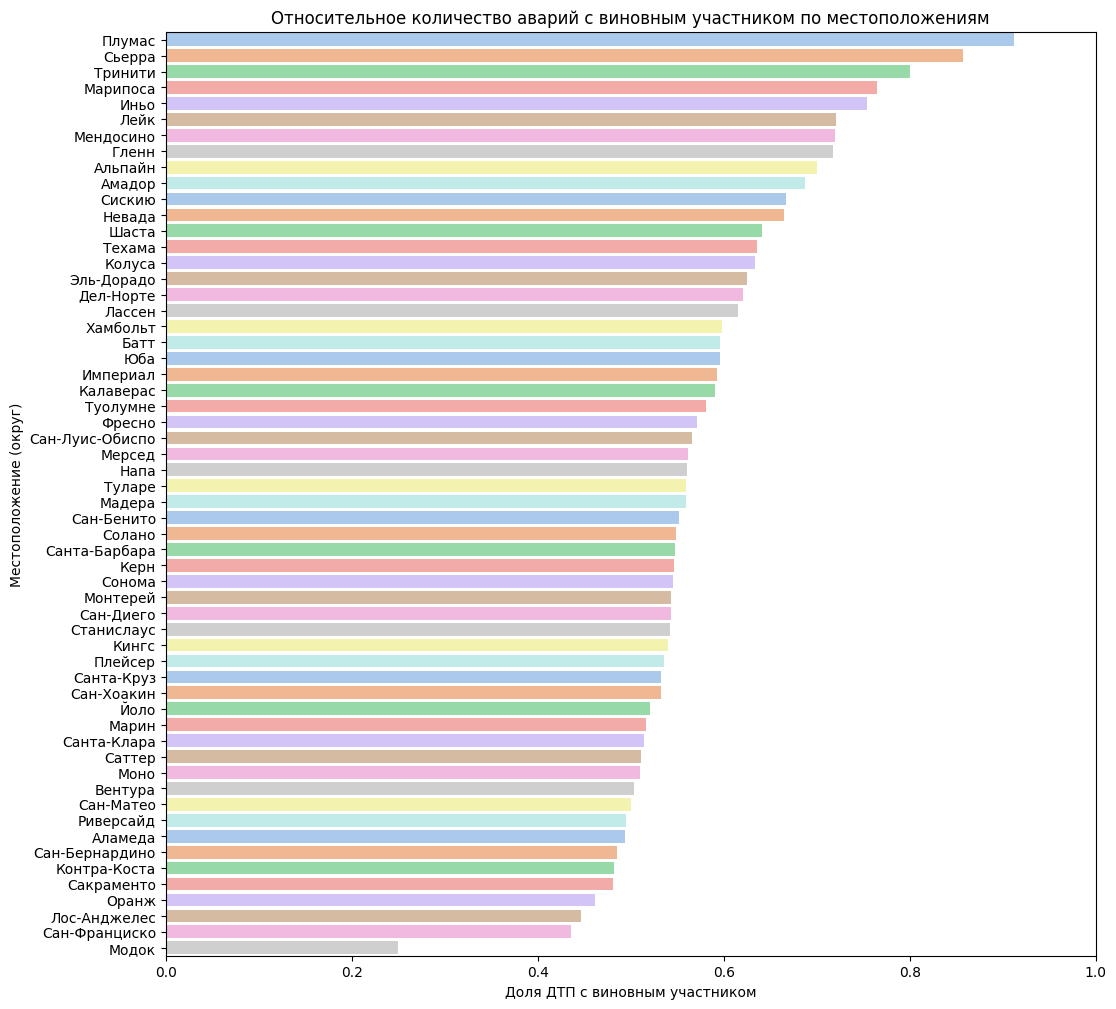

In [38]:
df_prepared_rus['Виновник ДТП (0 1)'] = df_prepared_rus['Виновник ДТП'].map({'Да': 1, 'Нет': 0})

# Группируем по местоположению и считаем долю
location_ratio = df_prepared_rus.groupby('Местоположение (округ)')['Виновник ДТП (0 1)'].mean()

# Сортируем по убыванию доли
location_ratio = location_ratio.sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 12))
sns.barplot(x=location_ratio.values, y=location_ratio.index, palette='pastel')
plt.xlabel('Доля ДТП с виновным участником')
plt.ylabel('Местоположение (округ)')
plt.title('Относительное количество аварий с виновным участником по местоположениям')
plt.xlim(0, 1)
plt.show()

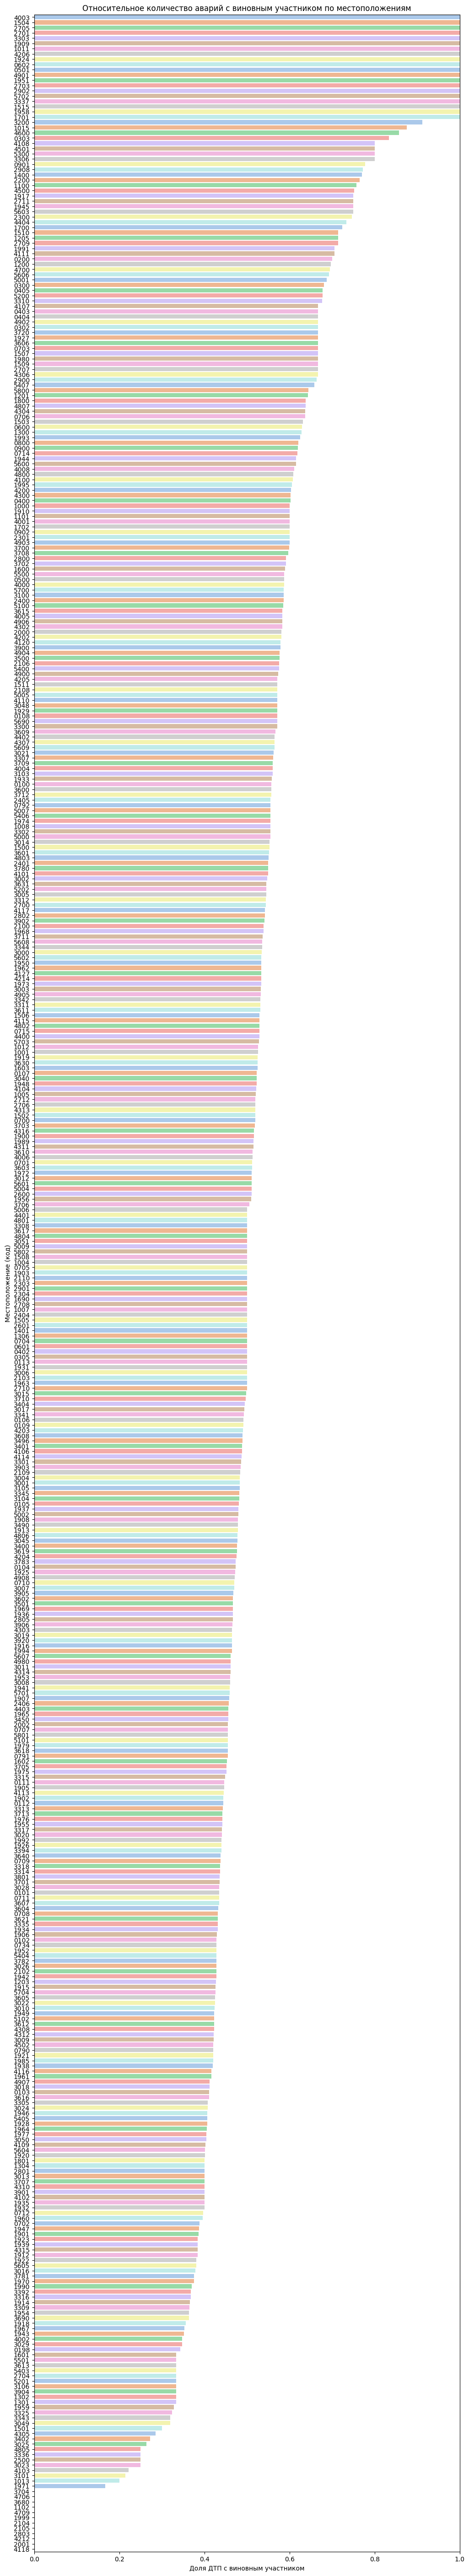

In [39]:
location_ratio = df_prepared_rus.groupby('Местоположение (код)')['Виновник ДТП (0 1)'].mean()

# Сортируем по убыванию доли
location_ratio = location_ratio.sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 72))
sns.barplot(x=location_ratio.values, y=location_ratio.index, palette='pastel')
plt.xlabel('Доля ДТП с виновным участником')
plt.ylabel('Местоположение (код)')
plt.title('Относительное количество аварий с виновным участником по местоположениям')
plt.xlim(0, 1)
plt.show()

Количество аварий с виной участника сильно различается в разных регионах. Однако в столбцах с местоположением 512 уникальный значений, что плохо скажется на скорости обучения и возможно на качестве модели.

Создадим числовой признак, куда запишем долю ДТП с виной водителя в текущем регионе. 

In [40]:
df_prepared['location_ratio'] = df_prepared['county_city_location'].map(location_ratio)

In [41]:
df_prepared_rus['Доля вины в регионе']=df_prepared['location_ratio']

Построим столбчатые диаграммы.

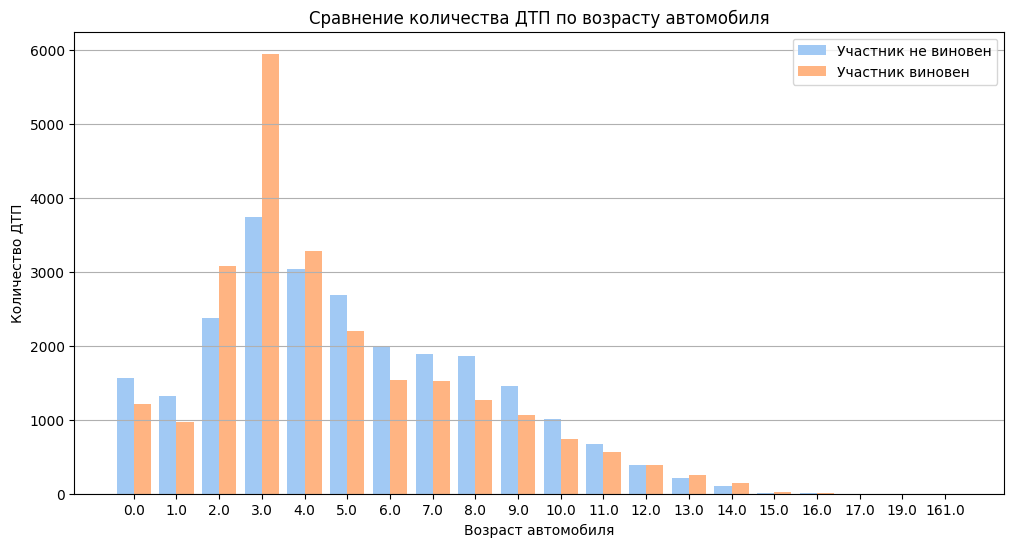

In [42]:
mylib.compare_2_bar_plots(df0, df1, 'Возраст автомобиля',
                    label1='Участник не виновен', 
                    label2='Участник виновен',
                    xlabel='Возраст автомобиля',
                    ylabel='Количество ДТП',
                    title='Сравнение количества ДТП по возрасту автомобиля')

Автомобиль с возрастом 161 год - это ошибка. 

В каршеринге автомобили старше 5 лет практически не найти. Возьмем возраст с двойным запасом и удалим из выборки автомобили с возрастом более 10 лет.

In [43]:
df_prepared = df_prepared[df_prepared["vehicle_age"] <= 10]

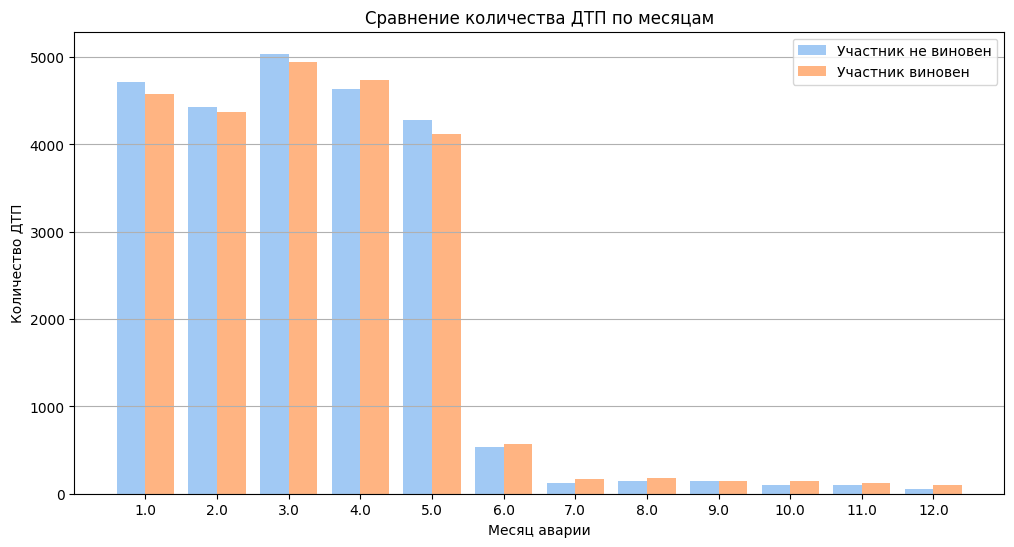

In [44]:
mylib.compare_2_bar_plots(df0, df1, 'Месяц',
                    label1='Участник не виновен', 
                    label2='Участник виновен',
                    xlabel='Месяц аварии',
                    ylabel='Количество ДТП',
                    title='Сравнение количества ДТП по месяцам')

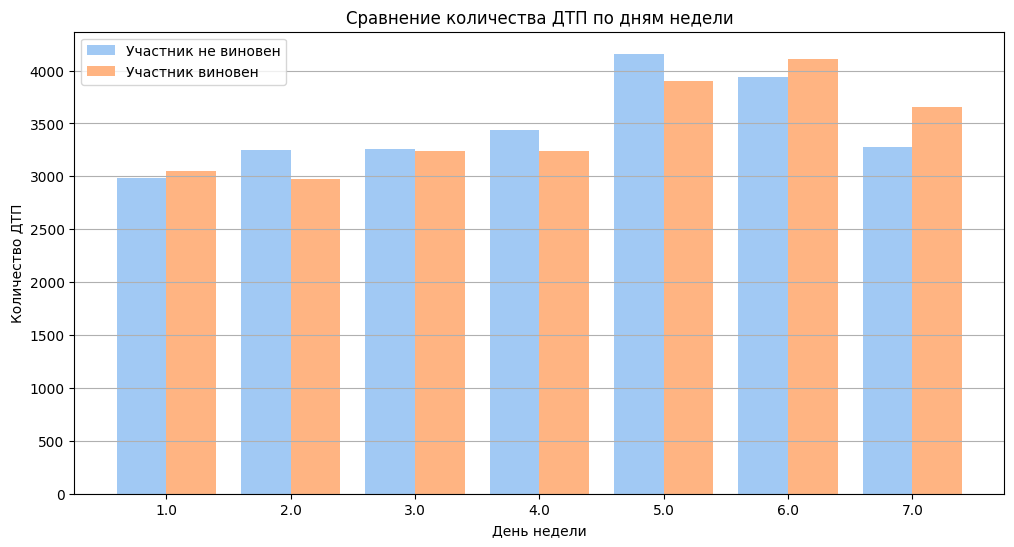

In [45]:
mylib.compare_2_bar_plots(df0, df1, 'День недели',
                    label1='Участник не виновен', 
                    label2='Участник виновен',
                    xlabel='День недели',
                    ylabel='Количество ДТП',
                    title='Сравнение количества ДТП по дням недели')

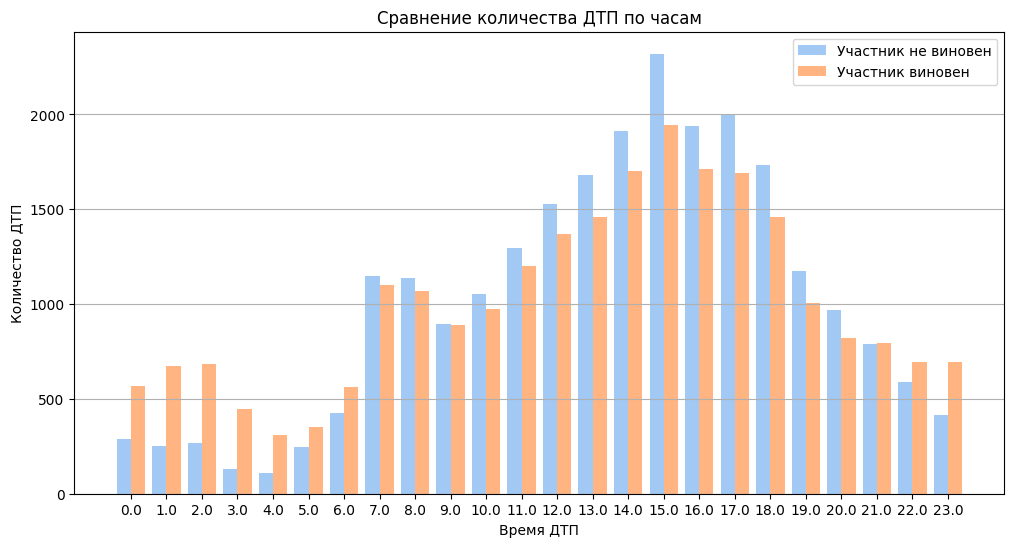

In [46]:
mylib.compare_2_bar_plots(df0, df1, 'Время',
                    label1='Участник не виновен', 
                    label2='Участник виновен',
                    xlabel='Время ДТП',
                    ylabel='Количество ДТП',
                    title='Сравнение количества ДТП по часам')

Можно сказать, что количество аварий с виной водителя возрастает в вечернее и ночное время, а также по субботам и воскресеньям.

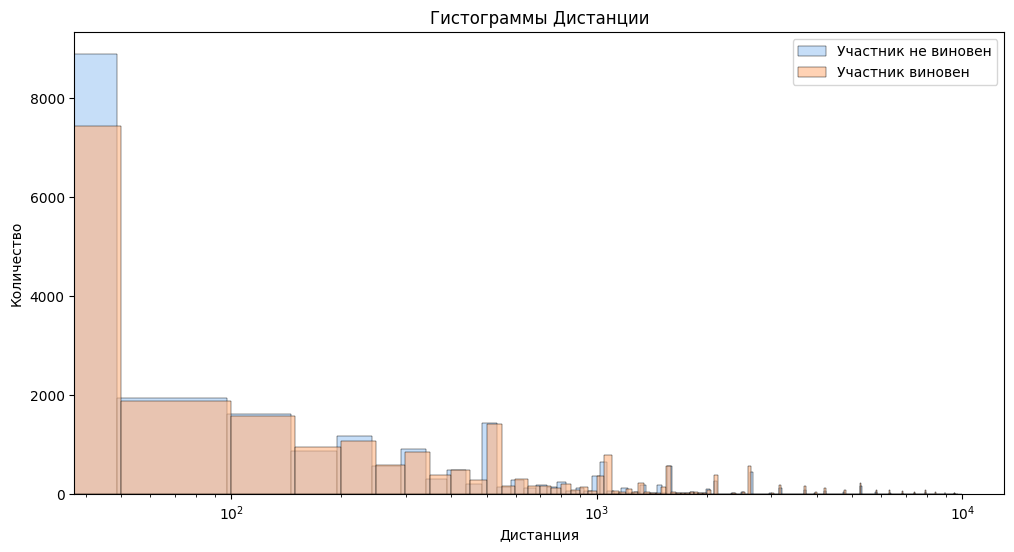

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(df0[df0['Дистанция'] < 10000]['Дистанция'].dropna(), 
             color='#a1c9f4', 
             label='Участник не виновен', 
             kde=False,
             alpha=0.6,
             bins=200)

sns.histplot(df1[df1['Дистанция'] < 10000]['Дистанция'].dropna(), 
             color='#ffb482', 
             label='Участник виновен', 
             kde=False,
             alpha=0.6,
             bins=200)

plt.xlabel('Дистанция')
plt.ylabel('Количество')
plt.title('Гистограммы Дистанции')
plt.legend()

# Логарифмическая шкала по оси X
plt.xscale('log')

plt.show()

Распределения дистанций с разбивкой по таргету повторяют друг друга. Заметной разницы нет.

**4.4 Корреляционный анализ**

In [48]:
# Вычисляем матрицу корреляции Phik
corr_matrix_phik = df_prepared_rus.drop(columns=['Виновник ДТП (0 1)']).phik_matrix(interval_cols=['Дистанция'])

# Выводим матрицу
corr_matrix_phik

,Перекрёсток,Погода,Поверхность дороги,Состояние дороги,Освещённость,Устройство регулирования,Дистанция,Направление,Местоположение (код),Местоположение (округ),Виновник ДТП,Трезвость водителя,Состояние водителя,Громкая связь,Тип автомобиля,Коробка передач,Возраст автомобиля,Месяц,День недели,Время,Доля вины в регионе
Перекрёсток,1.000000,0.033140,0.076178,0.076796,0.102080,0.718815,0.000000,0.867216,0.295519,0.115277,0.093345,0.094940,0.028425,0.020426,0.059166,0.033712,0.073508,0.031351,0.024516,0.082239,0.259366
Погода,0.033140,1.000000,0.679599,0.108886,0.059266,0.024907,0.000000,0.038290,0.368108,0.304349,0.051730,0.012984,0.021243,0.019467,0.025333,0.014357,0.008455,0.169623,0.104755,0.137179,0.331782
Поверхность дороги,0.076178,0.679599,1.000000,0.262163,0.040775,0.076244,0.000000,0.042513,0.475105,0.417887,0.108441,0.017675,0.027153,0.030332,0.020378,0.021308,0.037006,0.225380,0.053239,0.103085,0.451155
Состояние дороги,0.076796,0.108886,0.262163,1.000000,0.044997,0.081001,0.000000,0.057900,0.318774,0.205275,0.030835,0.014627,0.011652,0.008408,0.026266,0.000000,0.000000,0.034737,0.017381,0.081517,0.300809
Освещённость,0.102080,0.059266,0.040775,0.044997,1.000000,0.115350,0.000000,0.168507,0.340007,0.233796,0.069999,0.240374,0.108722,0.002271,0.064694,0.040645,0.204493,0.158159,0.092600,0.737915,0.329585
Устройство регулирования,0.718815,0.024907,0.076244,0.081001,0.115350,1.000000,0.000000,0.351915,0.342045,0.145731,0.125554,0.062629,0.025298,0.026669,0.033529,0.049867,0.084746,0.027340,0.039204,0.103639,0.320934
Дистанция,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.166778,0.000289,0.057194,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.108413
Направление,0.867216,0.038290,0.042513,0.057900,0.168507,0.351915,0.000000,1.000000,0.443744,0.222529,0.047068,0.049134,0.048889,0.012490,0.092050,0.016366,0.067044,0.032203,0.023056,0.074329,0.406083
Местоположение (код),0.295519,0.368108,0.475105,0.318774,0.340007,0.342045,0.000000,0.443744,1.000000,1.000000,0.156008,0.286169,0.255045,0.479421,0.234886,0.066560,0.217695,0.333738,0.212661,0.312867,1.000000
Местоположение (округ),0.115277,0.304349,0.417887,0.205275,0.233796,0.145731,0.166778,0.222529,1.000000,1.000000,0.131651,0.115507,0.094439,0.365590,0.150003,0.051227,0.078242,0.173048,0.080397,0.126104,0.999641


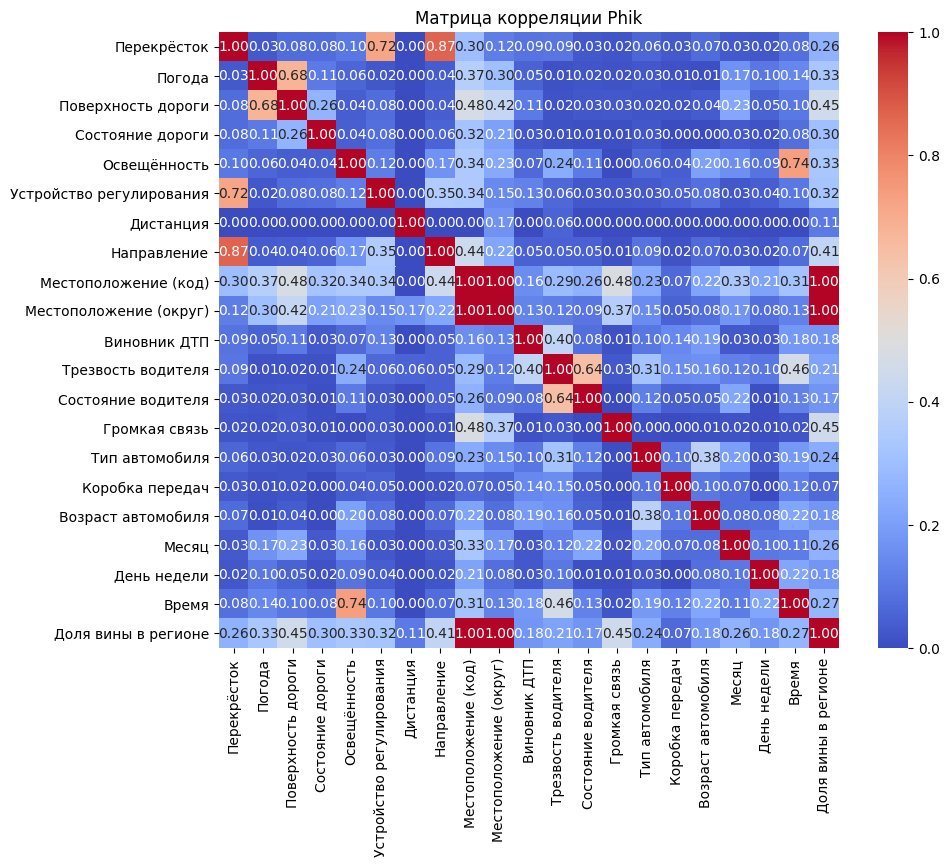

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_phik, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции Phik")
plt.show()

In [50]:
mylib.print_corr_levels(corr_matrix_phik, threshold = 0.1)

[('Весьма высокая корреляция между Местоположение (код) и Местоположение (округ):',
  1.0),
 ('Весьма высокая корреляция между Доля вины в регионе и Местоположение (код):',
  1.0),
 ('Весьма высокая корреляция между Доля вины в регионе и Местоположение (округ):',
  1.0),
 ('Высокая корреляция между Направление и Перекрёсток:', 0.867),
 ('Высокая корреляция между Время и Освещённость:', 0.738),
 ('Высокая корреляция между Перекрёсток и Устройство регулирования:', 0.719),
 ('Заметная корреляция между Поверхность дороги и Погода:', 0.68),
 ('Заметная корреляция между Состояние водителя и Трезвость водителя:', 0.645),
 ('Умеренная корреляция между Громкая связь и Местоположение (код):', 0.479),
 ('Умеренная корреляция между Местоположение (код) и Поверхность дороги:',
  0.475),
 ('Умеренная корреляция между Время и Трезвость водителя:', 0.464),
 ('Умеренная корреляция между Доля вины в регионе и Поверхность дороги:',
  0.451),
 ('Умеренная корреляция между Громкая связь и Доля вины в регио

Целевой признак имеет умеренную корреляцию с Трезвостью водителя и слабую корреляцию с Поверхностью дороги, Наличием устройства регулирования, Местоположением, Типом автомобиля, Коробкой передач, Возрастом автомобиля, Временем и Долей вины в регионе.

Доля вины в регионе и Местоположение код и округ имеют мультиколлинеарность. Оставим столбец Доля вины в регионе так как с ним больше корреляция целевого признака и модели будет проще обучаться на числовом непрерывном признаке, чем на категориальном признаке с 512 уникальными значениями.

**4.5 Подготовка данных к обучению**

По результатам статистического и корреляционного анализа выберем признаки для обучения моделей.

In [51]:
main_features = [
    'at_fault',
    'party_sobriety',
    'road_surface',
    'control_device',
    'vehicle_type',
    'vehicle_transmission',
    'vehicle_age',
    'hour',
    'location_ratio',
    'intersection',
    'party_drug_physical',
    'lighting'
]

In [52]:
# Категориальные признаки номинальные:
categorical_features = ['party_sobriety', 'road_surface', 'control_device', 'vehicle_type', 'vehicle_transmission', 'hour', 
                        'intersection', 'party_drug_physical', 'lighting']
# Количественные признаки:
numerical_features = ['vehicle_age', 'location_ratio']
# Целевой признак
target_feature = 'at_fault'

In [53]:
# Делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df_prepared.drop(target_feature, axis=1),
    df_prepared[target_feature],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE
)

print(f"Размеры выборок: X_train={X_train.shape}, X_test={X_test.shape}")

Размеры выборок: X_train=(34272, 20), X_test=(11424, 20)


**Промежуточный итог:**

В ходе подготовки данных для создания модели для предсказания риска ДТП была проведена выгрузка информации из базы данных. 

Проведена обработка пропусков. 

Проведен статистический и корреляционный анализ признаков, данные визуализированы. Произведен отбор наиболее важных признаков, влияющих на таргет.

Создан новый признак, заменяющий признак Местоположение.

Данные разделены на тренировочную и тестовую выборки.

<a class='anchor' id="link5"></a>
## 5 Поиск лучшей модели

Для решения задачи будем использовать Random Forest Classifier, LGBMClassifier, а также попробуем построить нейросетевую модель.

**5.1 Random Forest Classifier**

In [54]:
# pipeline для категориальных признаков
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(drop="first", handle_unknown='ignore', sparse_output=False))
])

# pipeline для числовых признаков
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# общий preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

In [55]:
# создаем итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [56]:
# Создадим сетку для перебора моделей и гиперпараметров
param_grid = [
    {
        'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20]
    }
]

In [57]:
# Запуск GridSearchCV для поиска лучшей модели и гиперпараметров
grid_RFC = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_RFC.fit(X_train, y_train)

# выведем параметры и метрику лучшей модели
print('Лучшая модель RandomForestClassifier и её параметры:\n    ', grid_RFC.best_params_)
print('\nМетрика ROC-AUC лучшей модели:', grid_RFC.best_score_) 

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшая модель RandomForestClassifier и её параметры:
     {'model': RandomForestClassifier(random_state=42), 'model__max_depth': 10, 'model__n_estimators': 200}

Метрика ROC-AUC лучшей модели: 0.7104227794253731


**5.2 LGBMClassifier**

In [58]:
# Создадим сетку для перебора моделей и гиперпараметров
param_grid = [
    {
        'model': [LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)],
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [-1, 10, 20],
        'model__learning_rate': [0.01, 0.05]
    }
]

In [59]:
# Запуск GridSearchCV для поиска лучшей модели и гиперпараметров
grid_LGBM = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_LGBM.fit(X_train, y_train)

# выведем параметры и метрику лучшей модели
print('Лучшая модель LGBMClassifier и её параметры:\n    ', grid_LGBM.best_params_)
print('\nМетрика ROC-AUC лучшей модели:', grid_LGBM.best_score_) 

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшая модель LGBMClassifier и её параметры:
     {'model': LGBMClassifier(random_state=42, verbose=-1), 'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 50}

Метрика ROC-AUC лучшей модели: 0.7127826059877632


**5.3 Нейросеть**

In [60]:
# Преобразуем данные
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Конвертируем в тензоры
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1,1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1,1), dtype=torch.float32)

In [61]:
# Создадим класс нейросети
class Net(nn.Module):
    def __init__(self, n_in, n_hidden1=16, n_hidden2=8, n_out=1, dropout=0.0):
        super(Net, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(n_in, n_hidden1),
            nn.LeakyReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.LeakyReLU(),
            nn.Linear(n_hidden2, n_out),
            nn.Sigmoid()  # для классификации
        )
    
    def forward(self, x):
        return self.model(x)

# Инициализация модели
n_features = X_train_tensor.shape[1]
net = Net(n_features)

def init_weights(layer):
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(layer.bias)

net.apply(init_weights)

# Функция потерь и оптимизатор
loss_fn = nn.BCELoss()  # для бинарной классификации
optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

In [62]:
# Функция обучения
def train_model(model, X_train, y_train, X_test, y_test, num_epochs=2000, patience=50):
    best_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    history_train = []
    history_test = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train)
        train_loss = loss_fn(preds, y_train)
        train_loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test)
            test_loss = loss_fn(test_preds, y_test)
        
        history_train.append(train_loss.item())
        history_test.append(test_loss.item())
        
        # Ранняя остановка
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}. Best test loss: {best_loss:.4f}")
                model.load_state_dict(best_model_state)
                break
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}")
    
    # График потерь
    plt.figure(figsize=(8,5))
    plt.plot(history_train, label='Train Loss')
    plt.plot(history_test, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train vs Test Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 1/1000 | Train Loss: 0.7260 | Test Loss: 0.7225
Epoch 101/1000 | Train Loss: 0.6397 | Test Loss: 0.6402
Epoch 201/1000 | Train Loss: 0.6115 | Test Loss: 0.6152
Epoch 301/1000 | Train Loss: 0.6060 | Test Loss: 0.6111
Epoch 401/1000 | Train Loss: 0.6030 | Test Loss: 0.6099
Epoch 501/1000 | Train Loss: 0.6006 | Test Loss: 0.6089
Epoch 601/1000 | Train Loss: 0.5982 | Test Loss: 0.6086
Epoch 701/1000 | Train Loss: 0.5962 | Test Loss: 0.6087
Early stopping at epoch 725. Best test loss: 0.6085


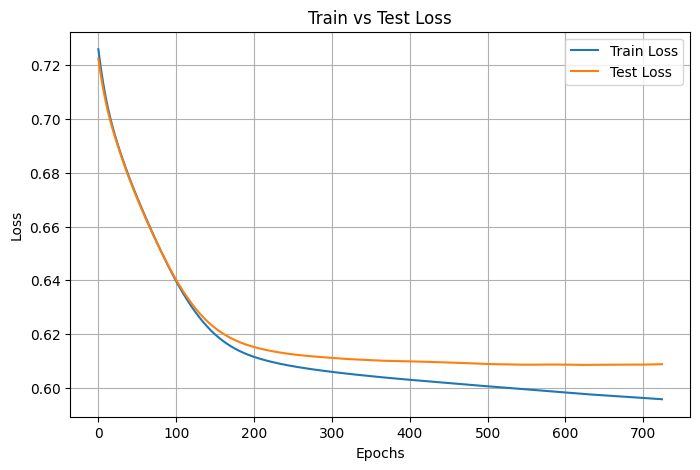

Метрика ROC-AUC: 0.7056493350917736


In [63]:
# Обучение модели
train_model(net, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, num_epochs=1000, patience=100)

# Предсказания
net.eval()
with torch.no_grad():
    y_pred = net(X_test_tensor).numpy().flatten()

# Конвертируем в 0/1
y_pred_class = (y_pred >= 0.5).astype(int)

# Метрика ROC-AUC
print("Метрика ROC-AUC:", roc_auc_score(y_test, y_pred))

**5.4 Анализ лучшей модели**

Все три модели показали близкие результаты. Лучшей моделью оказалась LGBMClassifier с ROC-AUC = 0.713. 

Построим матрицу ошибок для лучшей модели.

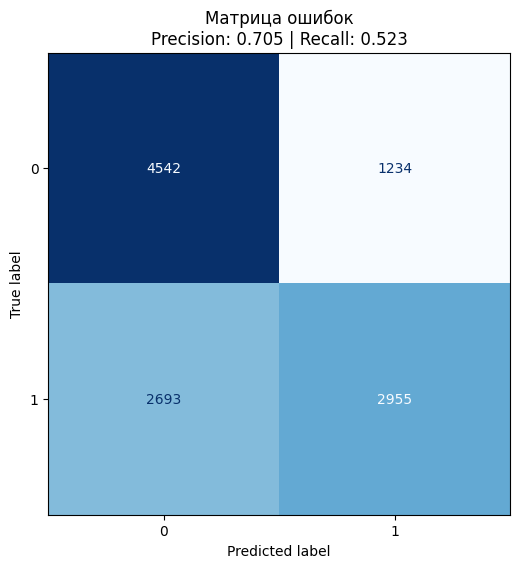

In [64]:
y_pred = grid_LGBM.predict(X_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

# Точность и полнота
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
plt.title(f'Матрица ошибок\nPrecision: {precision:.3f} | Recall: {recall:.3f}')
plt.show()

**5.5 Анализ важности признаков**

Проведем анализ важности признаков лучшей модели.

In [65]:
# Подготовим модель и данные
best_pipeline = grid_LGBM.best_estimator_
model = best_pipeline.named_steps['model']
X_train_encoded = best_pipeline['preprocessor'].transform(X_train)
X_test_encoded = best_pipeline['preprocessor'].transform(X_test)

In [66]:
explainer = shap.PermutationExplainer(model.predict_proba, X_train_encoded)

In [67]:
# Берем случайную подвыборку из X_test_encoded
sample_size = 500
sample_idx = np.random.choice(X_test_encoded.shape[0], size=sample_size, replace=False)
X_test_sample = X_test_encoded[sample_idx]

In [68]:
# Получаем SHAP значения только для подвыборки
shap_values = explainer(X_test_sample)

PermutationExplainer explainer: 501it [00:15, 14.81it/s]                                                               


In [69]:
try:
    # Пробуем получить имена признаков из препроцессора
    labels = best_pipeline['preprocessor'].get_feature_names_out()
except AttributeError:
    # Если не удаётся получить имена признаков, используем имена из X_train
    labels = X_train.columns
    
labels

array(['num__vehicle_age', 'num__location_ratio',
       'cat__party_sobriety_had been drinking, not under influence',
       'cat__party_sobriety_had been drinking, under influence',
       'cat__party_sobriety_had not been drinking',
       'cat__party_sobriety_impairment unknown',
       'cat__party_sobriety_not applicable', 'cat__road_surface_slippery',
       'cat__road_surface_snowy', 'cat__road_surface_wet',
       'cat__control_device_none', 'cat__control_device_not functioning',
       'cat__control_device_obscured', 'cat__vehicle_type_other',
       'cat__vehicle_type_sedan', 'cat__vehicle_transmission_manual',
       'cat__hour_1.0', 'cat__hour_2.0', 'cat__hour_3.0', 'cat__hour_4.0',
       'cat__hour_5.0', 'cat__hour_6.0', 'cat__hour_7.0', 'cat__hour_8.0',
       'cat__hour_9.0', 'cat__hour_10.0', 'cat__hour_11.0',
       'cat__hour_12.0', 'cat__hour_13.0', 'cat__hour_14.0',
       'cat__hour_15.0', 'cat__hour_16.0', 'cat__hour_17.0',
       'cat__hour_18.0', 'cat__hour_19.

In [70]:
labels_rus = [
    'num__Возраст автомобиля',
    'num__Доля аварий в локации',

    # party_sobriety
    'cat__Состояние водителя: пил, не под влиянием',
    'cat__Состояние водителя: пил, под влиянием',
    'cat__Состояние водителя: не пил',
    'cat__Состояние водителя: неизвестно',
    'cat__Состояние водителя: не применимо',

    # road_surface
    'cat__Поверхность дороги: скользкая',
    'cat__Поверхность дороги: заснеженная',
    'cat__Поверхность дороги: мокрая',

    # control_device
    'cat__Светофор: отсутствует',
    'cat__Светофор: не работает',
    'cat__Светофор: скрыт',

    # vehicle_type
    'cat__Тип автомобиля: другой',
    'cat__Тип автомобиля: седан',

    # vehicle_transmission
    'cat__Коробка передач: механика',

    # hours
    'cat__Время: 1:00',
    'cat__Время: 2:00',
    'cat__Время: 3:00',
    'cat__Время: 4:00',
    'cat__Время: 5:00',
    'cat__Время: 6:00',
    'cat__Время: 7:00',
    'cat__Время: 8:00',
    'cat__Время: 9:00',
    'cat__Время: 10:00',
    'cat__Время: 11:00',
    'cat__Время: 12:00',
    'cat__Время: 13:00',
    'cat__Время: 14:00',
    'cat__Время: 15:00',
    'cat__Время: 16:00',
    'cat__Время: 17:00',
    'cat__Время: 18:00',
    'cat__Время: 19:00',
    'cat__Время: 20:00',
    'cat__Время: 21:00',
    'cat__Время: 22:00',
    'cat__Время: 23:00',

    # intersection
    'cat__Перекресток',

    # party_drug_physical
    'cat__Физическое состояние: физическое нарушение',
    'cat__Физическое состояние: не применимо',
    'cat__Физическое состояние: сонливость/усталость',
    'cat__Физическое состояние: под воздействием наркотиков',

    # lighting
    'cat__Освещение: темно, фонари работают',
    'cat__Освещение: темно, фонари не работают',
    'cat__Освещение: дневное время',
    'cat__Освещение: сумерки/рассвет'
]

In [71]:
shap_values_fixed = shap.Explanation(
    values=shap_values.values[..., 1],
    base_values=shap_values.base_values[..., 1],  
    data=X_test_sample,  
    feature_names=labels_rus
)

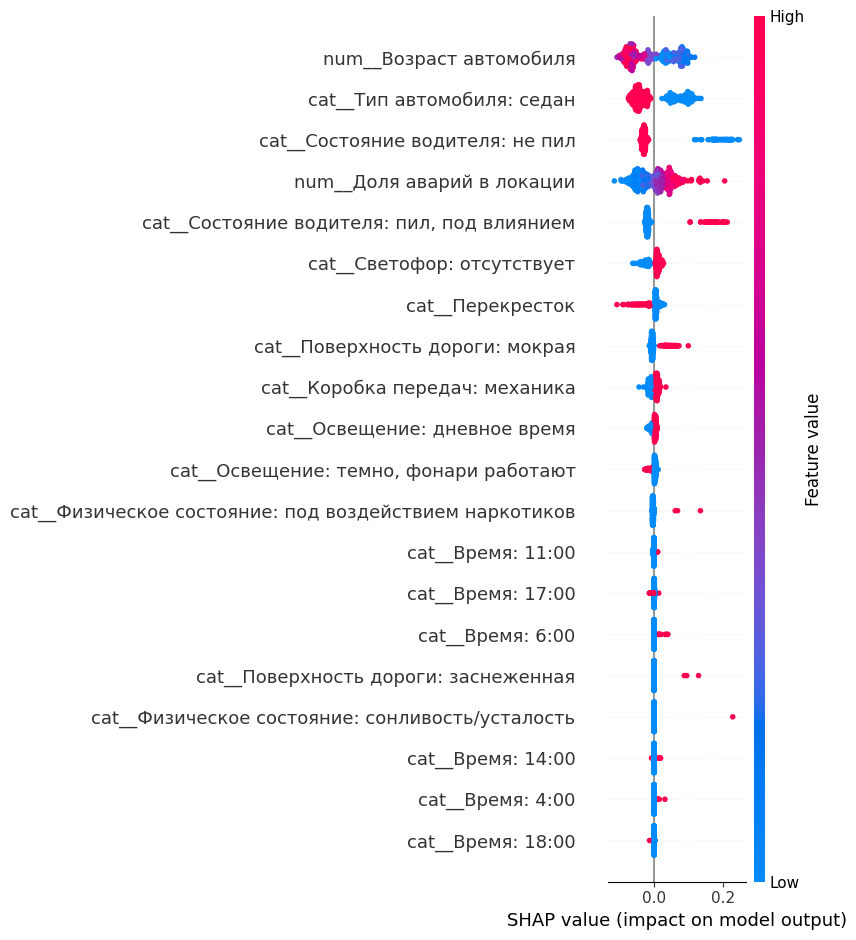

In [72]:
shap.summary_plot(shap_values_fixed, X_test_sample, feature_names=labels_rus, show=False)

Самыми важными признаками являются Возраст автомобиля, Тип автомобиля, Состояние водителя и Локация.

Одним из ключевых фактором влияющих на таргет является Состояние водителя. Для уменьшения вероятности ДТП предлагается ввести систему контроля за состоянием водителя. К примеру установить камеру, уоторая по внешнему виду водителя будет определять его усталость, сонливость, трезвость, адекватность состояния. На основе данной информации в начале или ходе движения можно делать предупреждения, или автоматически припарковывать автомобиль и включать аварийную сигнализацию.

Не менее важным признаком является доля ДТП по вине водителя в данной локации. Посмотрим на распределение данного признака с разбивкой по таргету.

In [73]:
df_prepared["location_ratio_cat"] = pd.cut(
    df_prepared["location_ratio"], 
    bins = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 
            0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0],
    labels = [
        "0.05", "0.10", "0.15", "0.20", "0.25",
        "0.30", "0.35", "0.40", "0.45", "0.50",
        "0.55", "0.60", "0.65", "0.70", "0.75",
        "0.80", "0.85", "0.90", "0.95", "1.0"
    ]
)

In [74]:
df_prepared_rus['Доля вины в регионе (кат)']=df_prepared['location_ratio_cat']

In [75]:
df0 = df_prepared_rus[df_prepared_rus['Виновник ДТП'] == 'Нет']
df1 = df_prepared_rus[df_prepared_rus['Виновник ДТП'] == 'Да']

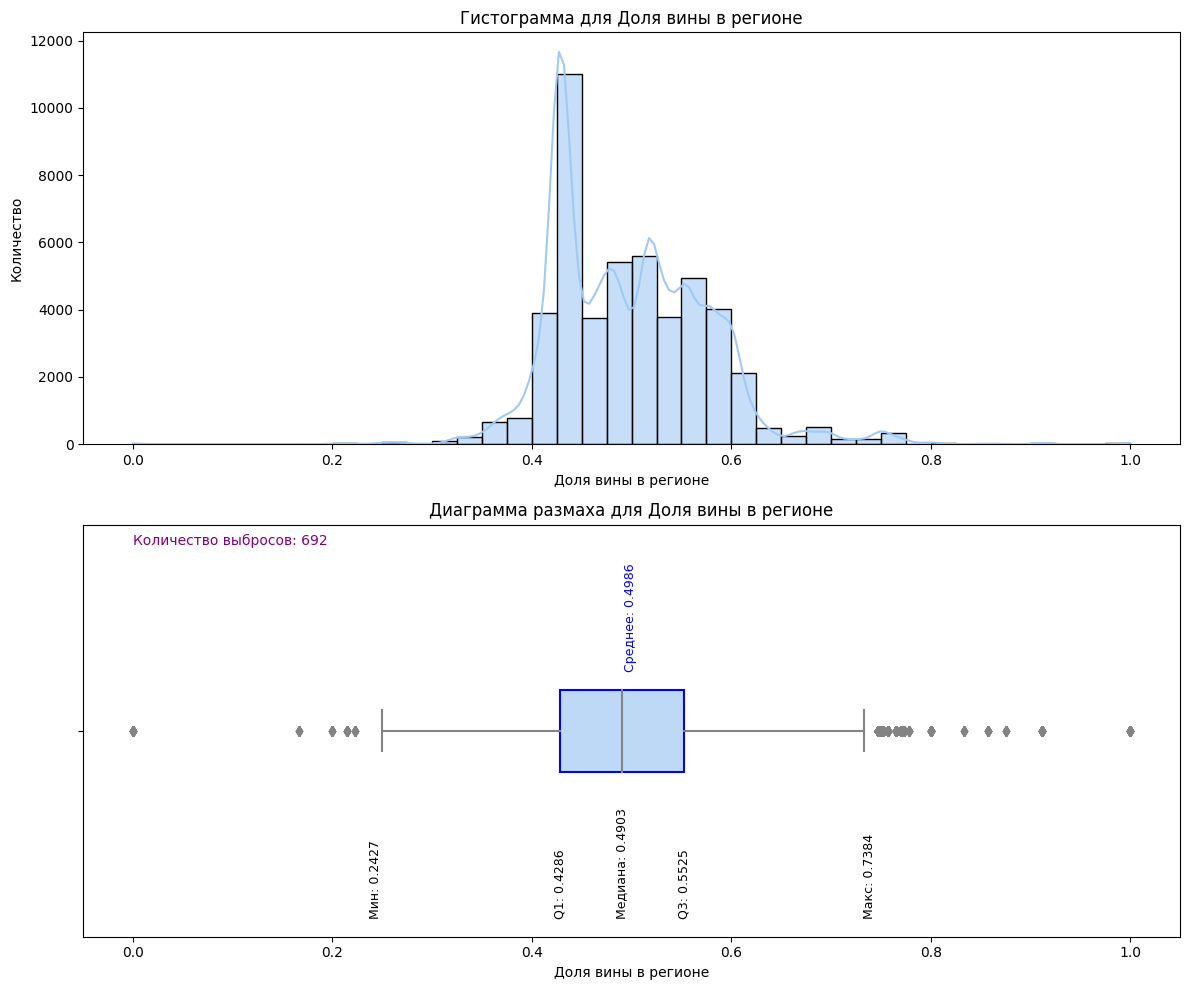

In [76]:
mylib.show_plot(df_prepared_rus, 'Доля вины в регионе', new_bins=40)

Большинство локаций имеют долю аварий по вине водителя около 50%. Межквартильный размах от 0,4286 до 0,5525.

Значения ниже 0,2427 и выше 0,7384 считаются аномальными.

Маршруты, пролегающие по локациям со значением данного признака менее 0,4286, можно считать относительно безопасными.

Маршруты, пролегающие по локациям со значением данного признака более 0,5525, можно считать относительно безопасными.

На основе данного признака можно создать систему, которая при задании точки назначения в навигаторе будет предлагать более безопасные маршруты.

**Промежуточный итог:**

Все три обученные модели продемонстрировали одинаковую слабую предсказательную способность. Лучшей моделью стала LGBMClassifier с метрикой ROC-AUC 0.713. 

Наибольее важными признаками являются: Возраст автомобиля, Тип автомобиля, Состояние водителя и Локация.

Были предложены варианты уменьшения влияния самых важных признаков на ДТП по вине водителя.

<a class='anchor' id="link6"></a>
## Общий вывод

**Целью работы** было:

Разработать модель для предсказания вероятности ДТП по вине водителя на основе имеющихся данных о ДТП, характеристиках автомобиля и состоянии участников.

**В ходе работ:**
- Выполнено подключение к базе данных и загрузка таблиц;
- Исследован состав данных, выявлены отсутствующие и аномальные признаки;
- Созданы аналистические задачи и проведен анализ признаков, влияющих на вероятность ДТП;
- Проведена обработка пропусков, статистический и корреляционный анализ признаков;
- Построены и обучены модели Random Forest Classifier, LGBMClassifier и нейросетевая модель;
- Проведен анализ важности признаков и их влияния на таргет.

**Ключевые результаты:**
- Целевой признак «Вина водителя» мало коррелирует с имеющимися данными;
- Наибольшее влияние на целевой признак оказывают: Возраст автомобиля, Тип автомобиля, Состояние водителя и Локация;
- Лучшей моделью стала LGBMClassifier с метрикой ROC-AUC 0.713;
- Точность предсказания обученых моделей низкая;
- Создание адекватной системы оценки риска при выдаче авто на данном этапе не возможно;
- Для продолжения исследования необходимо собирать дополнительные данные.


**Рекомендации:**

Для увеличения точности модели предлагается: 
- Добавить в датасет все поездки, а не только аварийные, для того чтобы можно было оценивать относительную аварийность маршрутов и связь вероятности ДТП с другими признаками;
- Добавить информацию о водителе: стаж вождения, количество аварий за последнее время и т.п.;
- Добавить другие факторы, которые известны до поездки, и которые могут влиять на вероятность ДТП;
- Изменить целевой признак на вероятность аварии в целом, а не только по вине водителя.